# Cinema Ticket Forecasting: EDA Notebook (rebuild)

**Goal of this notebook:** understand the data *before* modelling. It only loads, checks and plots. It does **not** write any new CSV.

**The big lesson from the first attempt:** `isna()` only finds empty *cells* in rows that exist. The real problems are usually **rows that are missing**, **keys that do not match** (movie titles!), and **a test set that is built differently from train**.

| Stage | Question we answer | Main graphic |
|---|---|---|
| 0 | What is in each file, and which time period does each cover? | timeline |
| 1 | How is the test question built? | window structure |
| 2 | Do the movie titles match across files? | before/after bars |
| 3 | Which rows are missing? | gap raster |
| 4 | What drives `total_ticket`? | trend, weekday, holiday, format |
| 5 | How do movies behave over time, and how big is the cold-start problem? | age curve, scatter |
| 6 | Is movie metadata useful and how complete is it? | coverage, genre, rating |
| 7 | Do city and ticket price matter? | price vs. tickets |

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})

DATA = "dataset/"        # the 7 CSVs from the zip
EXT  = "external_data/"  # acquisition_audit.csv, missing_movies_metadata.csv

## Stage 0: Load raw files and look at what we have

**What to do:** read every file, check `shape`, `dtypes`, and empty cells.

**Why:** it is the cheapest sanity check. But remember: **a clean `isna()` does not mean clean data.** It cannot see rows that should exist but do not.

**What to look for:** which files share the same columns, and which time period each file covers.

In [2]:
train     = pd.read_csv(DATA + "train.csv",           parse_dates=["date_show"])
test_hist = pd.read_csv(DATA + "test_history.csv",    parse_dates=["date_show"])
test      = pd.read_csv(DATA + "test.csv",            parse_dates=["date_show"])
movies    = pd.read_csv(DATA + "movies.csv")
holidays  = pd.read_csv(DATA + "holidays.csv",        parse_dates=["date"])
prices    = pd.read_csv(DATA + "ticket_prices.csv")
sample_sub= pd.read_csv(DATA + "sample_submission.csv")
ext_meta  = pd.read_csv(EXT  + "missing_movies_metadata.csv")
audit     = pd.read_csv(EXT  + "acquisition_audit.csv")

tables = {"train": train, "test_history": test_hist, "test": test, "movies": movies,
          "holidays": holidays, "ticket_prices": prices, "sample_submission": sample_sub,
          "ext_meta": ext_meta, "ext_audit": audit}

overview = pd.DataFrame({
    "rows":          {k: len(v) for k, v in tables.items()},
    "columns":       {k: v.shape[1] for k, v in tables.items()},
    "empty_cells":   {k: int(v.isna().sum().sum()) for k, v in tables.items()},
})
overview

,rows,columns,empty_cells
train,138959,7,0
test_history,32323,7,0
test,72611,5,0
movies,397,7,3
holidays,366,5,348
ticket_prices,207,3,0
sample_submission,72611,2,0
ext_meta,15,17,17
ext_audit,15,3,0


In [3]:
# Which columns does each table have?
for name, df in tables.items():
    print(f"{name:18s}", list(df.columns))

train              ['date_show', 'cinema_ids', 'city_name', 'movie_title', 'total_ticket', 'occupation_rate', 'total_show']
test_history       ['date_show', 'cinema_ids', 'city_name', 'movie_title', 'total_ticket', 'occupation_rate', 'total_show']
test               ['id', 'movie_title', 'cinema_ids', 'city_name', 'date_show']
movies             ['original_title', 'age_rating', 'genre', 'producer', 'director', 'writer', 'casts']
holidays           ['date', 'day_tipe', 'holiday_tipe', 'holiday_name', 'holiday_tier']
ticket_prices      ['city_name', 'ceil', 'price_day']
sample_submission  ['id', 'total_ticket']
ext_meta           ['original_title', 'age_rating', 'genre', 'producer', 'director', 'writer', 'casts', 'overview', 'popularity', 'runtime', 'original_language', 'release_year', 'released', 'imdb_id', 'imdb_rating', 'tmdb_id', 'movie_title_norm']
ext_audit          ['original_title', 'tmdb_id', 'result']


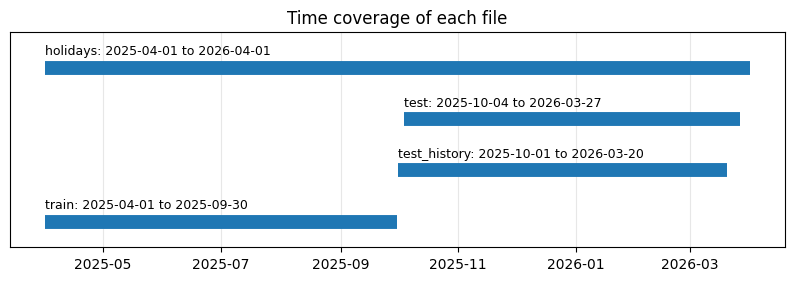

In [4]:
# Graphic: which period does each file cover?
spans = {
    "train":        (train.date_show.min(),     train.date_show.max()),
    "test_history": (test_hist.date_show.min(), test_hist.date_show.max()),
    "test":         (test.date_show.min(),      test.date_show.max()),
    "holidays":     (holidays.date.min(),       holidays.date.max()),
}
fig, ax = plt.subplots(figsize=(10, 2.8))
for i, (name, (a, b)) in enumerate(spans.items()):
    ax.hlines(i, a, b, linewidth=10)
    ax.text(a, i + 0.25, f"{name}: {a.date()} to {b.date()}", fontsize=9)
ax.set_yticks([]); ax.set_ylim(-0.5, len(spans) - 0.3)
ax.set_title("Time coverage of each file")
plt.show()

**What you should see:** train ends 30 Sep 2025, but test starts in Oct 2025 and runs to Mar 2026. So **we forecast a different season than we trained on** (Dec holidays, Imlek, Idulfitri 2026). Train alone cannot teach those periods, and `holidays.csv` is the only file that knows about them.

## Stage 1: How is the test question built?

**What to do:** look at test **per (cinema, movie) pair**: how many days to predict, and how much history we get.

**Why:** the way the test is built tells us what a *good validation* looks like later. If we do not copy this structure, our local score will lie to us.

In [5]:
keys = ["cinema_ids", "movie_title"]

pair_test = test.groupby(keys).date_show.agg(start="min", end="max", n_days="count")
pair_hist = test_hist.groupby(keys).date_show.agg(h_start="min", h_end="max", h_days="count")
pairs = pair_test.join(pair_hist, how="left")
pairs["h_days"] = pairs["h_days"].fillna(0).astype(int)
pairs["days_between"] = (pairs["start"] - pairs["h_end"]).dt.days

print("pairs in test:", len(pairs))
print("\ndays to predict per pair:\n", pairs.n_days.value_counts().to_string())
print("\nhistory days per pair:\n",    pairs.h_days.value_counts().sort_index().to_string())
print("\nday gap between end of history and start of test:\n", pairs.days_between.value_counts().to_string())

pairs in test: 10373

days to predict per pair:
 n_days
7    10373

history days per pair:
 h_days
1     189
2     730
3    9454

day gap between end of history and start of test:
 days_between
1    10373


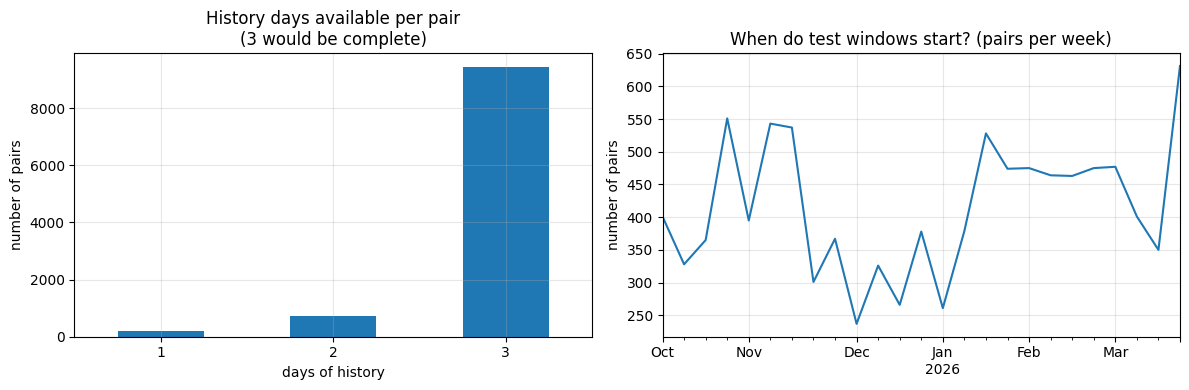

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pairs.h_days.value_counts().sort_index().plot.bar(ax=axes[0], rot=0)
axes[0].set_title("History days available per pair\n(3 would be complete)")
axes[0].set_xlabel("days of history"); axes[0].set_ylabel("number of pairs")

pairs.set_index("start").resample("W").size().plot(ax=axes[1])
axes[1].set_title("When do test windows start? (pairs per week)")
axes[1].set_xlabel(""); axes[1].set_ylabel("number of pairs")
plt.tight_layout(); plt.show()

**What you should see:** every pair has **exactly 7 test days**, starting the day **right after up to 3 history days**. Each pair has just **one window**, and windows are spread across Oct to Mar.

**Lessons**
- `test_history` is **not** a continuous record. It is a short 3-day look at each pair, right before its test window.
- The strongest clue for a pair's next 7 days is probably its own last 3 days. Later we will test this idea on train.
- `occupation_rate` and `total_show` exist in train and history but **not in test**. We can only use them as *past* information (from history), never for the days we predict.
- Some pairs have fewer than 3 history days. That is already a hint of missing rows (Stage 3).

## Stage 2: Do movie titles match across files?

**What to do:** build a *clean title* and compare it with the raw title.

**Why:** `movies.csv` has one row per movie, but the ticket files have rows like `HOPPERS (IMAX 2D)` or `AVATAR: FIRE AND ASH (3D)`. A plain join fails **silently**: no error, just empty features. This is another thing `isna()` cannot warn you about until after the join.

**Rule we follow:**
- `movie_title` (original) stays the grain of the data, because the test rows are at that level.
- `movie_base` (clean title) is used only to **join movie information** and to build movie-level views.
- `format` (REGULAR, 3D, IMAX 2D, IMAX 3D) is its own feature.

In [7]:
def base_title(s):
    s = str(s).upper().strip()
    s = re.sub(r"\s*\((?:IMAX\s*)?(?:2D|3D)\)\s*$", "", s)   # remove (3D) / (IMAX 2D) at the end
    s = re.sub(r"[^A-Z0-9 ]", " ", s)                          # remove punctuation like : - ' !
    return re.sub(r"\s+", " ", s).strip()                      # collapse spaces

def screen_format(s):
    m = re.search(r"\((IMAX\s*2D|IMAX\s*3D|2D|3D)\)\s*$", str(s).upper().strip())
    return re.sub(r"\s+", " ", m.group(1)) if m else "REGULAR"

for df in (train, test_hist, test):
    df["movie_base"] = df["movie_title"].map(base_title)
    df["format"]     = df["movie_title"].map(screen_format)

movies["movie_base"]   = movies["original_title"].map(base_title)
ext_meta["movie_base"] = ext_meta["original_title"].map(base_title)

# quick test of the cleaner
for t in ["HOPPERS (IMAX 2D)", "AVATAR: FIRE AND ASH (3D)", "MISSION: IMPOSSIBLE - THE FINAL RECKONING (IMAX 2D) "]:
    print(f"{t!r:62} -> {base_title(t)!r}, {screen_format(t)}")

'HOPPERS (IMAX 2D)'                                            -> 'HOPPERS', IMAX 2D
'AVATAR: FIRE AND ASH (3D)'                                    -> 'AVATAR FIRE AND ASH', 3D
'MISSION: IMPOSSIBLE - THE FINAL RECKONING (IMAX 2D) '         -> 'MISSION IMPOSSIBLE THE FINAL RECKONING', IMAX 2D


,1) raw title vs movies.csv,2) clean title vs movies.csv,3) clean title vs movies + external
table,,,
train,28,0,0
test_history,23,0,0
test,20,0,0


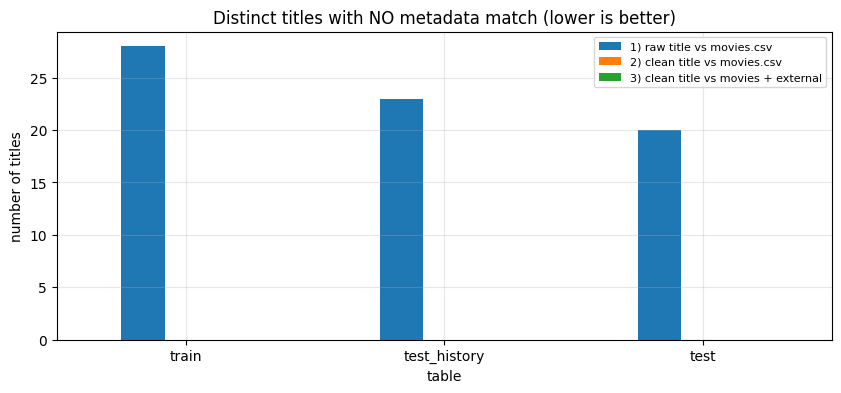

In [8]:
# How many distinct titles fail to match, under 3 different approaches?
raw_keys   = set(movies.original_title)
base_keys  = set(movies.movie_base)
ext_keys   = set(ext_meta.movie_base)

rows = []
for name, df in {"train": train, "test_history": test_hist, "test": test}.items():
    t = df[["movie_title", "movie_base"]].drop_duplicates()
    rows.append({
        "table": name,
        "1) raw title vs movies.csv":          int((~t.movie_title.isin(raw_keys)).sum()),
        "2) clean title vs movies.csv":        int((~t.movie_base.isin(base_keys)).sum()),
        "3) clean title vs movies + external": int((~t.movie_base.isin(base_keys | ext_keys)).sum()),
    })
unmatched = pd.DataFrame(rows).set_index("table")
display(unmatched)

ax = unmatched.plot.bar(rot=0, figsize=(10, 4))
ax.set_title("Distinct titles with NO metadata match (lower is better)")
ax.set_ylabel("number of titles"); ax.legend(fontsize=8)
plt.show()

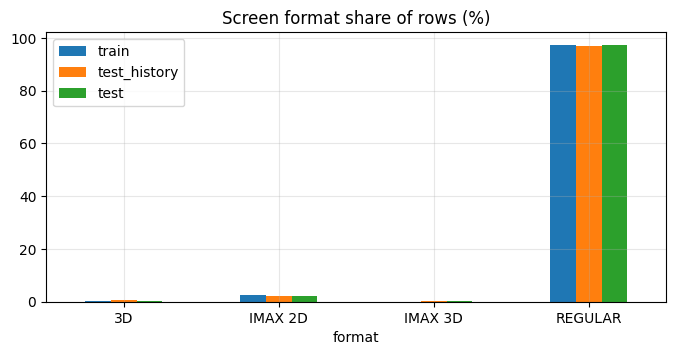

train: 4.5% of rows share cinema + clean title + date with another format row
test: 4.7% of rows share cinema + clean title + date with another format row


In [9]:
# Format mix and the "same movie, same cinema, same day" situation
fmt_share = pd.DataFrame({n: d["format"].value_counts(normalize=True) for n, d in
                          {"train": train, "test_history": test_hist, "test": test}.items()}).fillna(0) * 100
ax = fmt_share.plot.bar(rot=0, figsize=(8, 3.5))
ax.set_title("Screen format share of rows (%)"); plt.show()

for name, df in {"train": train, "test": test}.items():
    dup = df.duplicated(["cinema_ids", "movie_base", "date_show"], keep=False).mean() * 100
    print(f"{name}: {dup:.1f}% of rows share cinema + clean title + date with another format row")

**What you should see:** with the raw title, 20 to 28 titles per file have no match. With the clean title, **zero** are unmatched, and bar 3 is no better than bar 2.

**The surprise:** `movies.csv` already describes every movie once the titles are cleaned. The 15 movies that `missing_movies_metadata.csv` was made for were never really missing. Their titles just carried `(3D)` / `(IMAX 2D)` or punctuation (`AVATAR: FIRE AND ASH` vs `AVATAR FIRE AND ASH`). That is exactly what `acquisition_audit.csv` says ("normalized/deduplicated"). We confirmed it ourselves with the table above.

**Lessons**
- Always count *unmatched keys* before and after every join. This is the check that replaces "missing values look fine".
- About 5% of rows are the **same movie in two formats on the same day in the same cinema**. They are separate rows with separate targets in test, so we **do not merge them**. We only keep the format as a feature.

## Stage 3: Which rows are missing?

**What to do:** for each (cinema, movie) pair, compare the days that *exist* with the days between its first and last date.

**Why:** a row is only written when something was sold. We never see `total_ticket = 0`. So a missing day can mean **zero tickets**, not "unknown". If we model only the rows that exist, we learn from a **biased sample** (only days with sales) and will predict too high.

**What to look for:** how big the gaps are, whether they are random, and whether **test** has the same gaps.

In [10]:
g = train.groupby(keys).date_show.agg(first_day="min", last_day="max", n_rows="count")
g["span_days"]    = (g["last_day"] - g["first_day"]).dt.days + 1
g["missing_days"] = g["span_days"] - g["n_rows"]

print("pairs in train:                    ", len(g))
print("pairs with at least one gap:       ", int((g.missing_days > 0).sum()))
print("missing days inside run windows:   ", int(g.missing_days.sum()))
print(f"share of all in-window days missing: {g.missing_days.sum() / g.span_days.sum():.1%}")
print("smallest total_ticket in train:    ", train.total_ticket.min(), "(zero never appears)")
print("test pairs with gaps:              ", int(((pairs['end'] - pairs['start']).dt.days + 1 - pairs['n_days']).sum()), "(test is complete)")

pairs in train:                     13041
pairs with at least one gap:        3638
missing days inside run windows:    20386
share of all in-window days missing: 12.8%
smallest total_ticket in train:     1 (zero never appears)
test pairs with gaps:               0 (test is complete)


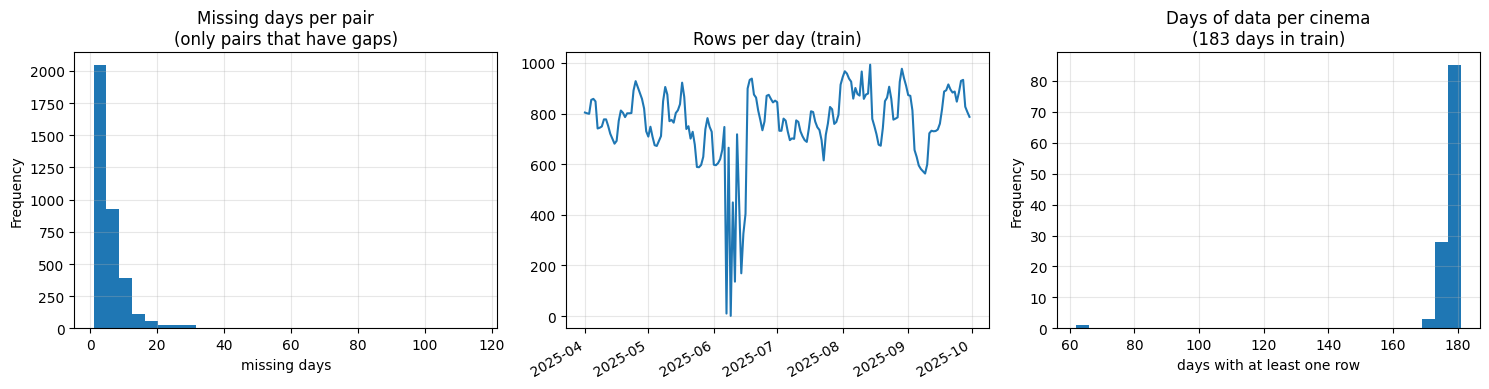

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

g.loc[g.missing_days > 0, "missing_days"].plot.hist(bins=30, ax=axes[0])
axes[0].set_title("Missing days per pair\n(only pairs that have gaps)"); axes[0].set_xlabel("missing days")

train.groupby("date_show").size().plot(ax=axes[1])
axes[1].set_title("Rows per day (train)"); axes[1].set_xlabel("")

train.groupby("cinema_ids").date_show.nunique().plot.hist(bins=30, ax=axes[2])
axes[2].set_title("Days of data per cinema\n(183 days in train)"); axes[2].set_xlabel("days with at least one row")
plt.tight_layout(); plt.show()

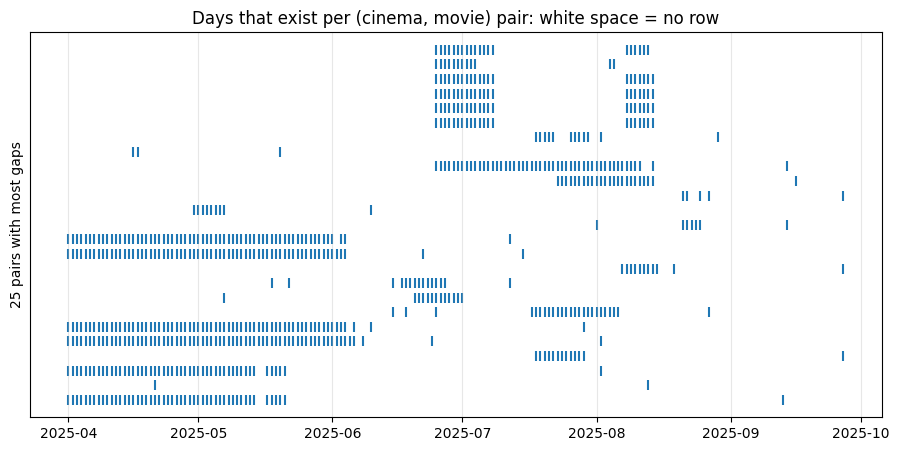

In [12]:
# Picture of the gaps: one line per pair, one tick per day that EXISTS. White space = missing day.
worst = g[(g.span_days >= 30) & (g.missing_days > 0)].sort_values("missing_days", ascending=False).head(25)
ylab  = {k: i for i, k in enumerate(worst.index)}
sub   = train[[k in ylab for k in zip(train.cinema_ids, train.movie_title)]]
ys    = [ylab[k] for k in zip(sub.cinema_ids, sub.movie_title)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(sub.date_show, ys, marker="|", s=60)
ax.set_yticks([]); ax.set_ylabel("25 pairs with most gaps")
ax.set_title("Days that exist per (cinema, movie) pair: white space = no row")
plt.show()

In [13]:
# Same check on test_history: how many pairs have fewer than 3 history days?
print(pairs.h_days.value_counts(normalize=True).sort_index().mul(100).round(1).rename("% of test pairs"))

h_days
1     1.8
2     7.0
3    91.1
Name: % of test pairs, dtype: float64


**What you should see:** about 1 in 8 days inside a movie's run has no row. Gaps are common in long runs: most pairs with 30+ days of life have at least one. The raster (these are the 25 *worst* pairs, so they are not typical) shows that gaps are mostly **long blocks**: a pair runs, disappears for weeks, then returns for a stray day or two. They are not random single missing days. Test, by contrast, is **fully complete: exactly 7 days for every pair**, and 9% of pairs have fewer than 3 history days (the history file has gaps too).

**Lessons**
- Train is **sparse** (days with no sales are absent), test is **dense** (every day must be predicted). They are built differently.
- A long block of absence usually means "not screened" (the movie left that cinema), while a lone missing day inside a busy run is more suspicious. Stray days far from a run also **stretch the span**, so the 12.8% figure mixes both cases. A sharper check is to measure gaps *only inside the main run*.
- Because zero never appears in train, a missing day most likely means **no tickets sold** (not screened, or sold out of showtimes). We cannot prove it from the data. This is an assumption to **test later on validation**: compare "leave gaps" with "fill gaps with 0".
- Rows per day grow as more cinemas join (see the middle plot), so totals over time mix "more demand" with "more cinemas". Prefer *per-row* averages when comparing days.

## Stage 4: What drives `total_ticket`?

**What to do:** look at the target on its own, then against time, weekday, holidays, screen format and number of shows.

**Why:** these plots tell us which features are worth building and what shape the target has (very skewed numbers usually need a log transform).

All merges below are **temporary, in memory, for plotting only**.

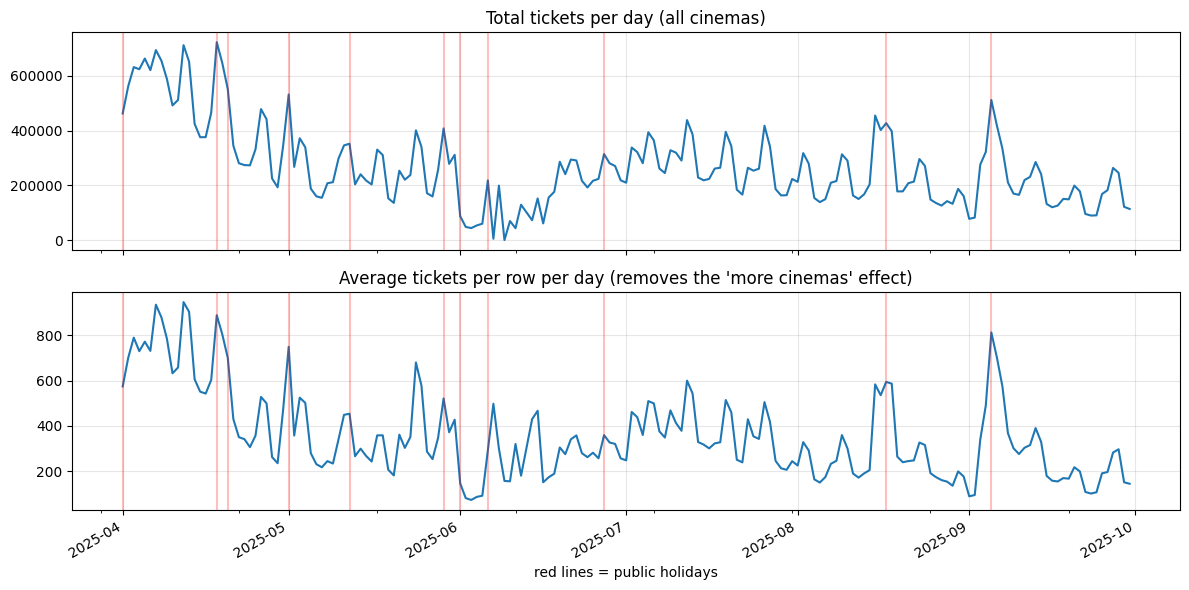

In [14]:
# Temporary join with the holiday calendar (many rows -> one row per date)
tr = train.merge(holidays, left_on="date_show", right_on="date", how="left", validate="m:1")
assert len(tr) == len(train) and tr.day_tipe.notna().all(), "holiday join changed rows or left blanks"

daily = tr.groupby("date_show").agg(total=("total_ticket", "sum"), rows=("total_ticket", "size"))
daily["per_row"] = daily.total / daily.rows
hol_days = holidays.loc[(holidays.holiday_tipe == "holiday") & holidays.date.between(train.date_show.min(), train.date_show.max()), "date"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
daily.total.plot(ax=axes[0]);   axes[0].set_title("Total tickets per day (all cinemas)")
daily.per_row.plot(ax=axes[1]); axes[1].set_title("Average tickets per row per day (removes the 'more cinemas' effect)")
for ax in axes:
    for h in hol_days: ax.axvline(h, color="red", alpha=0.25)
axes[1].set_xlabel("red lines = public holidays")
plt.tight_layout(); plt.show()

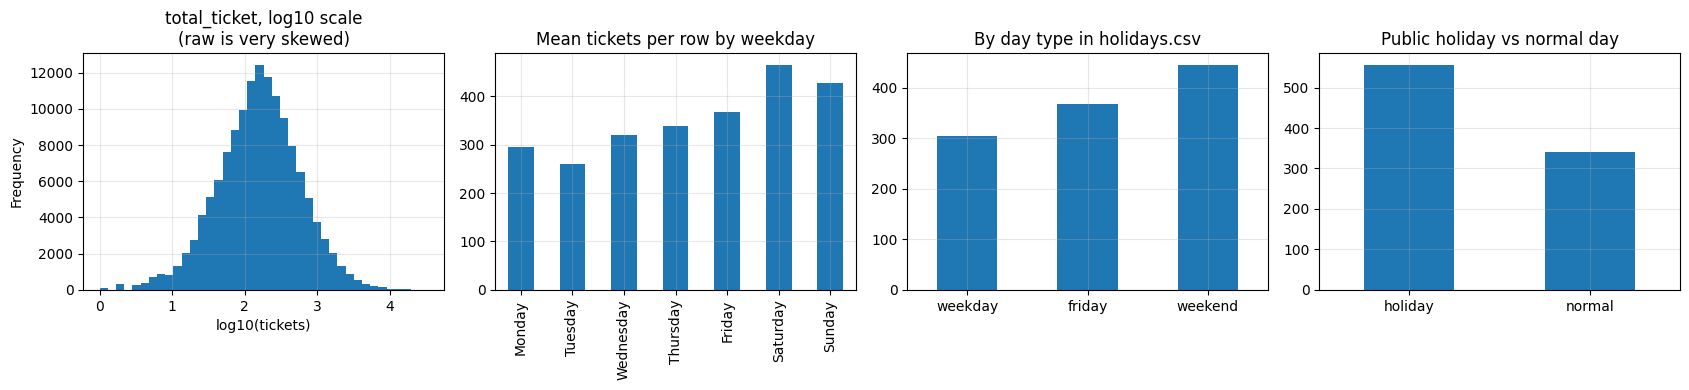

holiday days in train: 11 | in test period: 7


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

np.log10(tr.total_ticket).plot.hist(bins=40, ax=axes[0])
axes[0].set_title("total_ticket, log10 scale\n(raw is very skewed)"); axes[0].set_xlabel("log10(tickets)")

dow = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
tr.groupby(tr.date_show.dt.day_name()).total_ticket.mean().reindex(dow).plot.bar(ax=axes[1])
axes[1].set_title("Mean tickets per row by weekday"); axes[1].set_xlabel("")

tr.groupby("day_tipe").total_ticket.mean().reindex(["weekday", "friday", "weekend"]).plot.bar(ax=axes[2], rot=0)
axes[2].set_title("By day type in holidays.csv"); axes[2].set_xlabel("")

tr.groupby("holiday_tipe").total_ticket.mean().plot.bar(ax=axes[3], rot=0)
axes[3].set_title("Public holiday vs normal day"); axes[3].set_xlabel("")
plt.tight_layout(); plt.show()

print("holiday days in train:", int((tr.drop_duplicates('date_show').holiday_tipe == 'holiday').sum()), "| in test period:",
      int(holidays.loc[holidays.date.between(test.date_show.min(), test.date_show.max()), 'holiday_tipe'].eq('holiday').sum()))

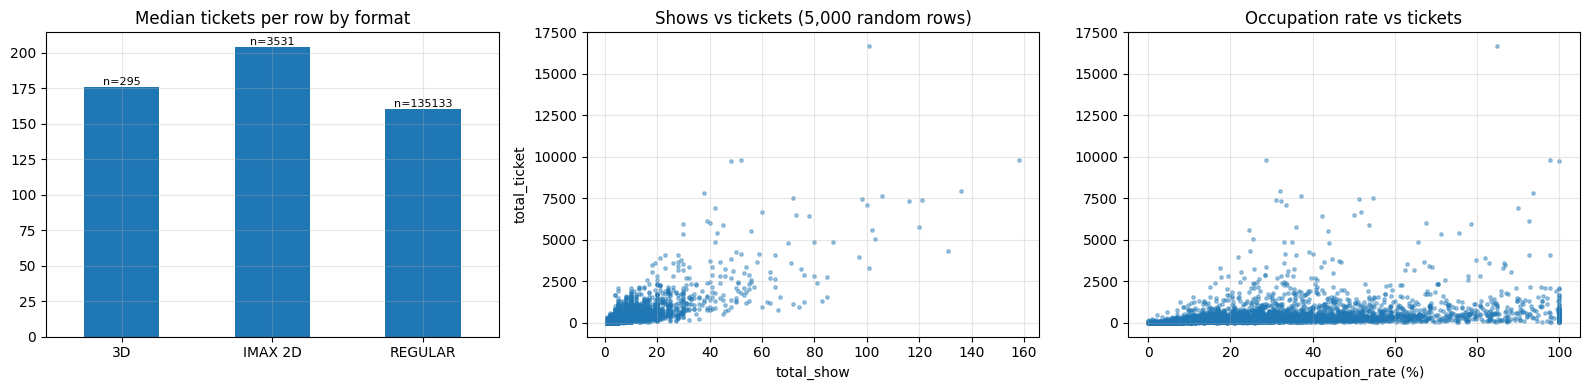

correlation total_show vs total_ticket: 0.786


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

fmt = tr.groupby("format").total_ticket.agg(median="median", n="size")
fmt["median"].plot.bar(ax=axes[0], rot=0)
for i, (m, n) in enumerate(zip(fmt["median"], fmt["n"])): axes[0].text(i, m, f"n={n}", ha="center", va="bottom", fontsize=8)
axes[0].set_title("Median tickets per row by format"); axes[0].set_xlabel("")

s = tr.sample(5000, random_state=0)
axes[1].scatter(s.total_show, s.total_ticket, s=6, alpha=0.4)
axes[1].set_title("Shows vs tickets (5,000 random rows)"); axes[1].set_xlabel("total_show"); axes[1].set_ylabel("total_ticket")

axes[2].scatter(s.occupation_rate, s.total_ticket, s=6, alpha=0.4)
axes[2].set_title("Occupation rate vs tickets"); axes[2].set_xlabel("occupation_rate (%)")
plt.tight_layout(); plt.show()
print("correlation total_show vs total_ticket:", round(tr.total_show.corr(tr.total_ticket), 3))

**What you should see:** a long right tail (many small days, a few huge ones). Saturday and Sunday average roughly 430 to 465 tickets per row against about 260 to 340 on Monday to Thursday, with Friday in between. Public holidays average about 560 against about 340 on normal days. For format, the **median** is higher for IMAX 2D (about 204) and 3D (about 176) than REGULAR (about 160), but the **mean** of REGULAR is higher because it has a few very big days, so be careful which number you quote. `total_show` and tickets correlate at about 0.79.

**Lessons**
- Model **log(tickets)** or a count-aware loss, not raw tickets.
- Calendar features (weekday, `day_tipe`, holiday flag, days to/from a holiday) are cheap and useful. The **test period has holidays train never saw** (Natal, Tahun Baru, Imlek, Nyepi, Idulfitri 2026), so a flag like "is holiday" generalises while "which holiday" does not.
- `total_show` is very predictive but **not available in test**. It is only a clue from history. Never feed it in as a same-day feature.

## Stage 5: Movie life cycle and the cold-start problem

**What to do:** (a) see how tickets change with a movie's age, (b) measure how much of test involves things train has never seen, (c) imitate the test setup on train ("first 3 days" to "next 7 days").

**Why:** most test movies are new releases. If tickets decay with movie age, and the first days predict the next days, then history is our best feature.

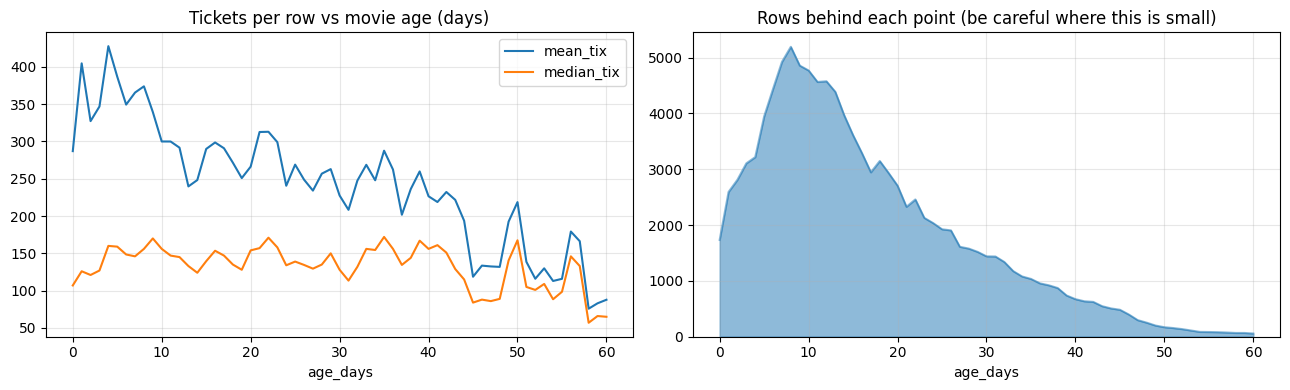

movies used: 184


In [17]:
# (a) Tickets by days since the movie first appeared in train.
#     We skip movies already running on day 1 of the data, because their real start is unknown.
first_seen = train.groupby("movie_base").date_show.min().rename("first_seen")
t = train.join(first_seen, on="movie_base")
t = t[t.first_seen >= train.date_show.min() + pd.Timedelta(days=14)].copy()
t["age_days"] = (t.date_show - t.first_seen).dt.days

curve = t[t.age_days <= 60].groupby("age_days").total_ticket.agg(mean_tix="mean", median_tix="median", n_rows="size")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
curve[["mean_tix", "median_tix"]].plot(ax=axes[0]); axes[0].set_title("Tickets per row vs movie age (days)")
curve.n_rows.plot.area(ax=axes[1], alpha=0.5);      axes[1].set_title("Rows behind each point (be careful where this is small)")
plt.tight_layout(); plt.show()
print("movies used:", t.movie_base.nunique())

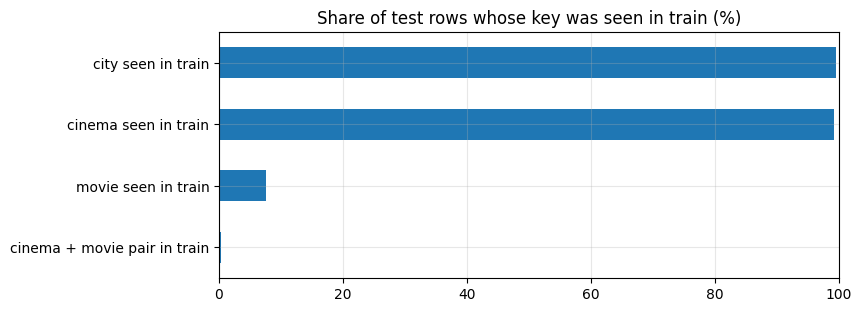

test cinemas not in train: ['2df461316312ad73a45a7b7354c24014', 'ab66df99207da01f3e300ef0163a1d2e', 'ea8d354888b056f56de16e2ce54e3415', 'f3432c52947b6412b4973fa6bf23d666']
test cities  not in train: ['MAGELANG', 'TUBAN']


In [18]:
# (b) How much of test is unseen in train?  (share of TEST ROWS)
train_pair = train[["cinema_ids", "movie_base"]].drop_duplicates().assign(seen=True)
pair_seen  = test[["cinema_ids", "movie_base"]].merge(train_pair, how="left", on=["cinema_ids", "movie_base"])["seen"].notna()

cold = pd.Series({
    "movie seen in train":           test.movie_base.isin(set(train.movie_base)).mean(),
    "cinema seen in train":          test.cinema_ids.isin(set(train.cinema_ids)).mean(),
    "city seen in train":            test.city_name.isin(set(train.city_name)).mean(),
    "cinema + movie pair in train":  pair_seen.mean(),
}) * 100

ax = cold.sort_values().plot.barh(figsize=(8, 3.2))
ax.set_title("Share of test rows whose key was seen in train (%)"); ax.set_xlim(0, 100)
plt.show()
print("test cinemas not in train:", sorted(set(test.cinema_ids) - set(train.cinema_ids)))
print("test cities  not in train:", sorted(set(test.city_name)  - set(train.city_name)))

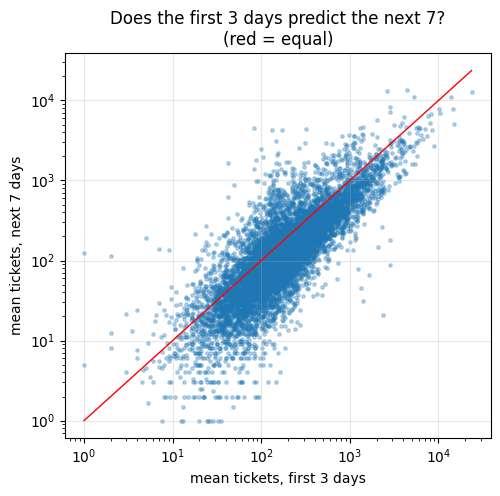

pairs used: 8886 | correlation of logs: 0.812


In [19]:
# (c) Imitate the test setup on train:  first 3 days of a pair  ->  next 7 days of the same pair
pair_first = train.groupby(keys).date_show.transform("min")
tt = train.assign(pair_first=pair_first)
tt = tt[tt.pair_first >= train.date_show.min() + pd.Timedelta(days=14)].copy()
tt["d"] = (tt.date_show - tt.pair_first).dt.days

first3 = tt[tt.d.between(0, 2)].groupby(keys).total_ticket.mean().rename("first3")
next7  = tt[tt.d.between(3, 9)].groupby(keys).total_ticket.mean().rename("next7")
ab = pd.concat([first3, next7], axis=1, join="inner")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(ab.first3, ab.next7, s=6, alpha=0.3)
lim = [ab.min().min(), ab.max().max()]; ax.plot(lim, lim, color="red", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("mean tickets, first 3 days"); ax.set_ylabel("mean tickets, next 7 days")
ax.set_title("Does the first 3 days predict the next 7?\n(red = equal)")
plt.show()
print("pairs used:", len(ab), "| correlation of logs:", round(np.log(ab.first3).corr(np.log(ab.next7)), 3))

**What you should see:** tickets **rise for roughly the first week, then decay** (about 290 on day 0, about 365 around day 7, about 120 by day 45; the right end of the curve rests on few rows). In test, only about **8% of rows** have a movie that appears in train, and only **0.3%** have an exact cinema + movie pair seen in train, while cinema and city are known for about 99%. The "first 3 days vs next 7 days" scatter follows the red line closely (log correlation around 0.8).

**Lessons**
- Treat test as a **cold-start** problem. Features that need a long train history for that exact pair will be empty. Features built from the **3 history days**, **cinema level**, **city level** and **movie metadata** will be filled.
- Part (c) is also your **blueprint for validation**: build windows on train that look like test (3 days known, then 7 to predict), and score on those. A random row split would leak and look too good.

## Stage 6: Movie metadata: how complete, and is there signal?

**What to do:** measure how many rows get movie information (raw title vs clean title), check what the external file really adds, then compare average demand by age rating and genre. Everything is **in memory only**.

**Watch out:** the two sources write genres differently (`Action, War` vs `Action|Adventure`), so we split them into lists before using them.

external movies that are ALSO in movies.csv (clean title): 15 of 15
age_rating identical in both files: 1.0


,movie_base,genre_ext,genre_movies
0,AVATAR FIRE AND ASH,Sci-Fi|Adventure|Fantasy,"Sci-Fi, Adventure, Fantasy"
1,BLADES OF THE GUARDIANS,Action|Adventure,"Action, History"
2,DANUR THE LAST CHAPTER,Horror|Mystery|Thriller,Horror
3,EPIC ELVIS PRESLEY IN CONCERT,Music|Documentary,Documentary
4,HOPPERS,Adventure|Animation|Comedy|Family|Sci-Fi,Animation



movies with an empty age_rating: ['MLBB: M7 WATCH PARTY - TIER\xa0LEGEND', 'MLBB: M7 WATCH PARTY - TIER\xa0MYTHIC', 'TWENTY ONE PILOTS: MORE THAN WE EVER IMAGINED']


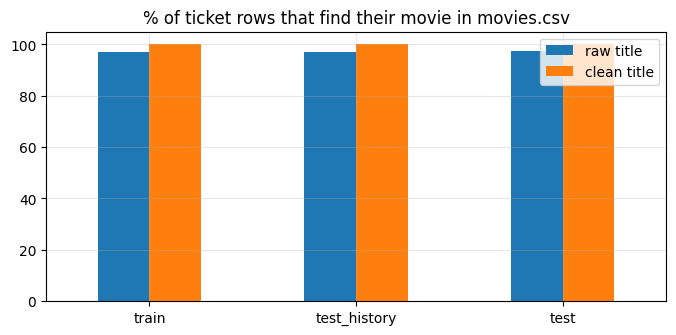

In [20]:
meta = movies[["movie_base", "age_rating", "genre"]].copy()
meta["genre_list"] = meta.genre.str.split(",").map(lambda xs: [x.strip() for x in xs])   # "Action, War" -> ["Action", "War"]

# 1) What does the external file add compared with movies.csv?
cmp = ext_meta[["movie_base", "age_rating", "genre"]].merge(
        movies[["movie_base", "age_rating", "genre"]], on="movie_base",
        suffixes=("_ext", "_movies"), validate="1:1")
print("external movies that are ALSO in movies.csv (clean title):", len(cmp), "of", len(ext_meta))
print("age_rating identical in both files:", (cmp.age_rating_ext == cmp.age_rating_movies).mean())
display(cmp[["movie_base", "genre_ext", "genre_movies"]].head(5))
print("\nmovies with an empty age_rating:", movies.loc[movies.age_rating.isna(), "original_title"].tolist())

# 2) Share of ticket rows that find a movie row, raw title vs clean title
cov = pd.DataFrame({
    "raw title":   {n: d.movie_title.isin(set(movies.original_title)).mean() * 100 for n, d in {"train": train, "test_history": test_hist, "test": test}.items()},
    "clean title": {n: d.movie_base.isin(set(meta.movie_base)).mean() * 100 for n, d in {"train": train, "test_history": test_hist, "test": test}.items()},
})
ax = cov.plot.bar(rot=0, figsize=(8, 3.5)); ax.set_ylim(0, 105)
ax.set_title("% of ticket rows that find their movie in movies.csv"); plt.show()

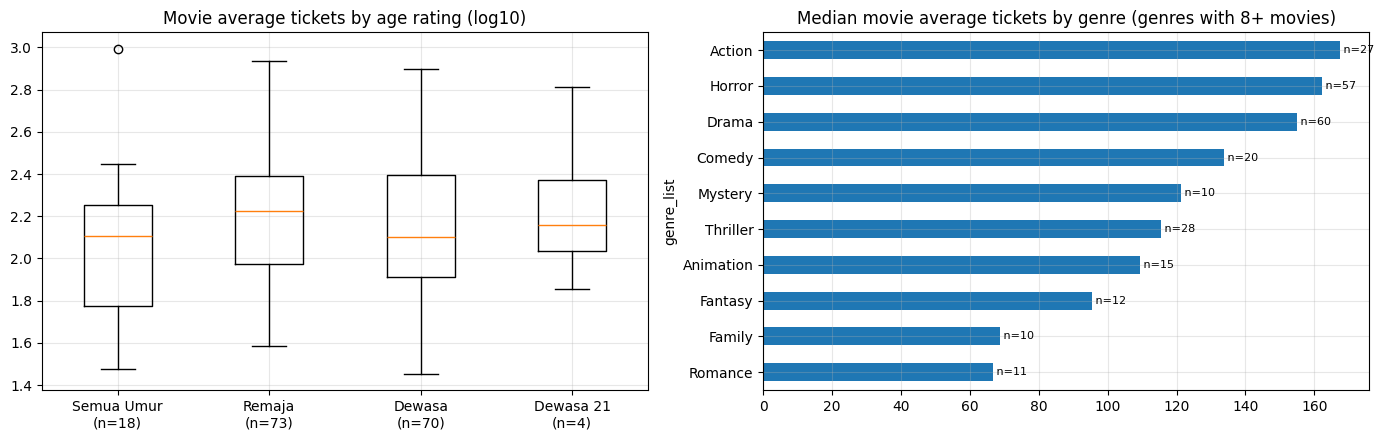

In [21]:
# Movie-level view: average tickets per row for each movie (train only), joined to metadata
mt = train.groupby("movie_base").total_ticket.agg(mean_tix="mean", n_rows="size").reset_index()
mt = mt[mt.n_rows >= 50].merge(meta, on="movie_base", how="left", validate="1:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

order = ["Semua Umur", "Remaja", "Dewasa", "Dewasa 21"]
data  = [np.log10(mt.loc[mt.age_rating == a, "mean_tix"]) for a in order]
axes[0].boxplot(data, tick_labels=[f"{a}\n(n={len(d)})" for a, d in zip(order, data)])
axes[0].set_title("Movie average tickets by age rating (log10)")

gx = mt.explode("genre_list").groupby("genre_list").mean_tix.agg(median="median", n="size")
gx = gx[gx.n >= 8].sort_values("median")
gx["median"].plot.barh(ax=axes[1])
for i, (m, n) in enumerate(zip(gx["median"], gx["n"])): axes[1].text(m, i, f" n={n}", va="center", fontsize=8)
axes[1].set_title("Median movie average tickets by genre (genres with 8+ movies)")
plt.tight_layout(); plt.show()

In [22]:
# The external file has extra columns. How many movies actually have them?
extras = ["overview", "popularity", "runtime", "original_language", "release_year", "released", "imdb_id", "imdb_rating", "tmdb_id"]
all_titles = pd.concat([train.movie_base, test_hist.movie_base, test.movie_base]).nunique()
filled = ext_meta[extras].notna().sum().to_frame("movies with a value")
filled["out of all movies in ticket files"] = all_titles
filled

,movies with a value,out of all movies in ticket files
overview,15,341
popularity,15,341
runtime,15,341
original_language,15,341
release_year,15,341
released,15,341
imdb_id,15,341
imdb_rating,0,341
tmdb_id,15,341


**What you should see:** with raw titles a visible share of rows finds no movie, with clean titles it is 100%. The external file agrees with `movies.csv` on age rating for all 15 movies and mainly gives **longer genre lists**. The 3 movies with an empty age rating are events (MLBB watch parties and a Twenty One Pilots film), and the external file does not cover them. In the charts, `Remaja` has the highest median (about 168 tickets per row per movie) and Action, Horror and Drama sit at the top of the genre chart while Romance and Family sit at the bottom. The extra external columns (popularity, runtime, release date...) exist for only **15 of 341 movies**, and `imdb_rating` is empty for all of them.

**Lessons**
- Use **age rating and genre** (as multi-label flags) as movie features. They exist for every movie once titles are cleaned. Treat the 3 event titles as their own case.
- **Do not** use popularity, runtime or release date as features: they are empty for about 96% of movies, and the 15 that have them are all recent releases, so the feature would simply mean "is a new release".
- Be honest about small groups: `Dewasa 21` has only 4 movies, and a genre with 8 or 10 movies can easily be noise.

## Stage 7: City and ticket price

**What to do:** look at price levels per city and compare them with average demand per city.

**Why:** the price table has 3 rows per city (Weekday, Friday, Weekend). We want to know if price carries information beyond "which city is this".

**Assumption to remember:** `day_tipe` in `holidays.csv` (weekday / friday / weekend) maps to `price_day` (Weekday / Friday / Weekend). Public holidays on a weekday are still labelled `weekday` in that file, so we assume they use the weekday price. The files do not confirm this.

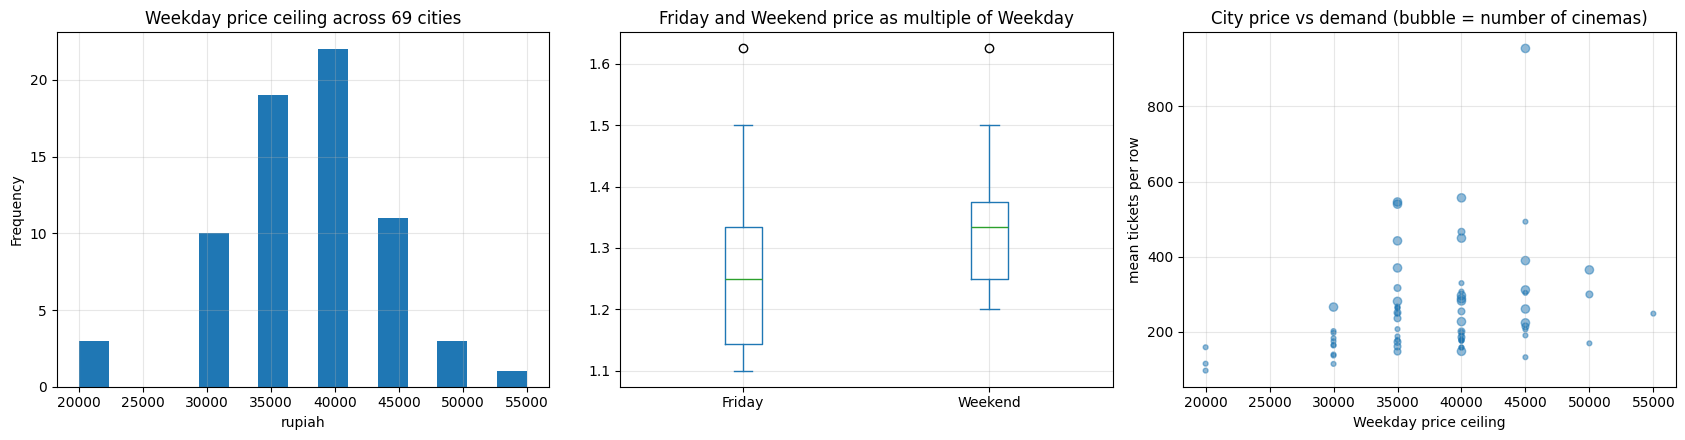

correlation price vs mean tickets (cities): 0.305
price rows per city: [3]


In [23]:
price_wide = prices.pivot(index="city_name", columns="price_day", values="ceil")[["Weekday", "Friday", "Weekend"]]
city = train.groupby("city_name").agg(mean_tix=("total_ticket", "mean"), cinemas=("cinema_ids", "nunique"))
city = city.join(price_wide, how="left")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

price_wide.Weekday.plot.hist(bins=15, ax=axes[0]); axes[0].set_title("Weekday price ceiling across 69 cities"); axes[0].set_xlabel("rupiah")

(price_wide.div(price_wide.Weekday, axis=0)[["Friday", "Weekend"]]).plot.box(ax=axes[1])
axes[1].set_title("Friday and Weekend price as multiple of Weekday")

axes[2].scatter(city.Weekday, city.mean_tix, s=city.cinemas * 12, alpha=0.5)
axes[2].set_xlabel("Weekday price ceiling"); axes[2].set_ylabel("mean tickets per row")
axes[2].set_title("City price vs demand (bubble = number of cinemas)")
plt.tight_layout(); plt.show()

print("correlation price vs mean tickets (cities):", round(city.Weekday.corr(city.mean_tix), 3))
print("price rows per city:", prices.groupby("city_name").size().unique())

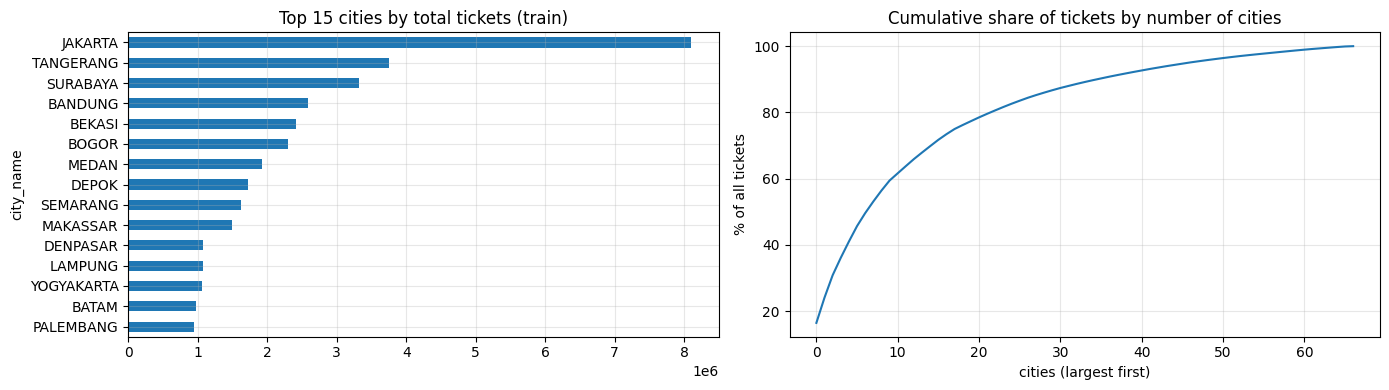

In [24]:
# Which cities carry the volume?  (concentration)
top = train.groupby("city_name").total_ticket.sum().sort_values(ascending=False)
share = (top.cumsum() / top.sum() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
top.head(15).sort_values().plot.barh(ax=axes[0]); axes[0].set_title("Top 15 cities by total tickets (train)")
share.reset_index(drop=True).plot(ax=axes[1]);     axes[1].set_title("Cumulative share of tickets by number of cities")
axes[1].set_xlabel("cities (largest first)"); axes[1].set_ylabel("% of all tickets")
plt.tight_layout(); plt.show()

**What you should see:** Friday prices are typically about 1.25x the Weekday price and Weekend about 1.33x, so the ratio is fairly stable. City price and city demand are only weakly related (correlation about 0.3), while the **number of cinemas in a city** relates more strongly to average tickets (about 0.5). The top 5 cities carry about 41% of tickets and the top 10 about 59%.

**Lessons**
- Price adds a day-type-specific number, so it can be a feature, but it mostly says "which city" and will overlap with city and cinema identity.
- Because a few cities dominate, check your validation score **per city group** later, not only overall.
- Train has 67 cities, test has 69 (Magelang and Tuban are new), and 4 test cinemas are new. Those rows need features that do not depend on train history for that cinema or city.

## Summary: what the EDA tells us to do next

| Finding | Decision for modelling |
|---|---|
| Test = 3 history days, then 7 days to predict, per pair | Build validation windows on train that copy this |
| Most test pairs and movies are unseen in train | Lean on history, cinema, city and movie metadata features |
| Raw titles do not match; clean titles do. `movies.csv` is then complete | Always join through `movie_base`, and count unmatched keys after every join |
| Train has missing days, test does not; zero never appears | Test "gaps = 0" vs "leave gaps" on validation |
| Target is very skewed and has weekday/holiday/format effects | Use log target, calendar features, format feature |
| `total_show` and `occupation_rate` are not in test | Use only as past (history) information |
| External file covers only 15 movies and mostly duplicates `movies.csv` | Use age rating and genre. Skip popularity, runtime, release date |
| 4 test cinemas and 2 test cities are new | Features need fallbacks (city or national averages) |

**Next notebook stage (when you are ready):** build the validation set, then the first baseline (e.g. repeat the mean of the last 3 days) so every later model has a score to beat.

## Stage 8: Abnormal days (the early June drop)

**What to do**: Build one row per calendar day. Count rows, cinemas, movies, shows and tickets. Flag days that look far below the usual level.

**Why**: A day can look low because people stayed home, or because data is missing. Those are different problems, and a model should not treat them the same way.

**What to look for**: Which days get red flags, and whether the flags match what you already found (1 to 5 June, then 7, 9, 10 and 11 June).

In [25]:
# --- settings you can change ---
WINDOW      = 29     # days used to find the "usual" level
FEW_CINEMAS = 0.80   # flag if cinemas are below 80% of usual
FEW_SHOWS   = 0.65   # flag if shows per row are below 65% of usual

# one row per date, built from train
daily = train.groupby("date_show").agg(
    rows=("total_ticket", "size"),
    cinemas=("cinema_ids", "nunique"),
    movies=("movie_title", "nunique"),
    total_show=("total_show", "sum"),
    tickets=("total_ticket", "sum"),
)

# add calendar days that have no rows at all (they would be invisible otherwise)
all_days = pd.date_range(train.date_show.min(), train.date_show.max(), freq="D")
daily = daily.reindex(all_days).rename_axis("date_show")
print("calendar days with no rows at all:", int(daily.rows.isna().sum()))
count_cols = ["rows", "cinemas", "movies", "total_show", "tickets"]
daily[count_cols] = daily[count_cols].fillna(0)

# per-row measures (a day with 0 rows gets NaN, not a fake number)
daily["shows_per_row"]   = daily.total_show / daily.rows.replace(0, np.nan)
daily["tickets_per_row"] = daily.tickets    / daily.rows.replace(0, np.nan)

# "usual" level = median of the 29 days around each day (centered)
def usual(s):
    return s.rolling(WINDOW, center=True, min_periods=7).median()

daily["cinemas_usual"] = usual(daily.cinemas)
daily["shows_usual"]   = usual(daily.shows_per_row)
daily["cinemas_ratio"] = daily.cinemas / daily.cinemas_usual
daily["shows_ratio"]   = daily.shows_per_row / daily.shows_usual

# the two flags
daily["few_cinemas"] = daily.cinemas_ratio < FEW_CINEMAS
daily["few_shows"]   = daily.shows_ratio   < FEW_SHOWS
daily["flag_type"] = np.select(
    [daily.few_cinemas & daily.few_shows, daily.few_cinemas, daily.few_shows],
    ["both", "few cinemas", "few shows per row"],
    default="ok",
)

# small table of flagged days (in memory only)
flagged = daily[daily.flag_type != "ok"]
cols = ["rows", "cinemas", "cinemas_usual", "shows_per_row", "shows_usual", "tickets_per_row", "flag_type"]
print(len(flagged), "flagged days out of", len(daily), "\n")
display(flagged[cols].round(1))

calendar days with no rows at all: 1
13 flagged days out of 183 



,rows,cinemas,cinemas_usual,shows_per_row,shows_usual,tickets_per_row,flag_type
date_show,,,,,,,
2025-06-01,598.0,114.0,115.0,3.4,7.9,146.2,few shows per row
2025-06-02,596.0,113.0,115.0,3.4,7.6,81.1,few shows per row
2025-06-03,604.0,113.0,115.0,3.2,6.9,72.9,few shows per row
2025-06-04,620.0,114.0,115.0,3.3,6.7,86.5,few shows per row
2025-06-05,656.0,115.0,115.0,3.0,6.7,91.6,few shows per row
2025-06-07,10.0,10.0,115.0,3.5,6.7,498.1,both
2025-06-09,1.0,1.0,115.0,1.0,6.7,157.0,both
2025-06-10,449.0,67.0,115.0,7.1,6.7,155.2,few cinemas
2025-06-11,136.0,76.0,115.0,5.9,6.7,320.3,few cinemas


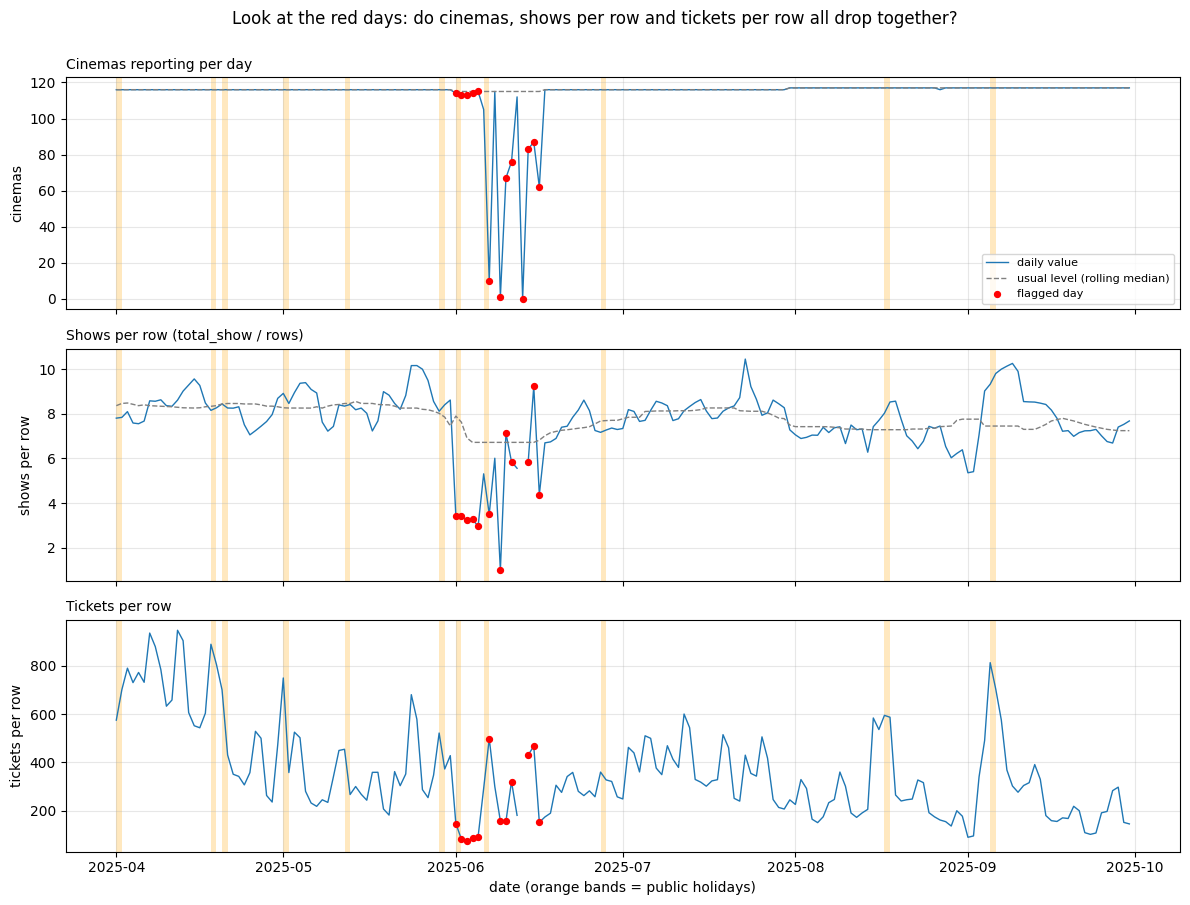

In [26]:
hol_all   = holidays.loc[holidays.holiday_tipe == "holiday", "date"]
hol_train = hol_all[hol_all.between(daily.index.min(), daily.index.max())]
bad = daily.flag_type != "ok"

panels = [
    ("cinemas",         "cinemas_usual", "Cinemas reporting per day",         "cinemas"),
    ("shows_per_row",   "shows_usual",   "Shows per row (total_show / rows)", "shows per row"),
    ("tickets_per_row", None,            "Tickets per row",                   "tickets per row"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, (col, usual_col, title, ylab) in zip(axes, panels):
    ax.plot(daily.index, daily[col], color="tab:blue", lw=1, label="daily value")
    if usual_col:
        ax.plot(daily.index, daily[usual_col], color="gray", ls="--", lw=1, label="usual level (rolling median)")
    ax.scatter(daily.index[bad], daily.loc[bad, col], color="red", s=18, zorder=3, label="flagged day")
    for h in hol_train:                       # light orange band = public holiday
        ax.axvspan(h, h + pd.Timedelta(days=1), color="orange", alpha=0.25, lw=0)
    ax.set_title(title, fontsize=10, loc="left")
    ax.set_ylabel(ylab)
axes[0].legend(fontsize=8, loc="lower right")
axes[-1].set_xlabel("date (orange bands = public holidays)")
fig.suptitle("Look at the red days: do cinemas, shows per row and tickets per row all drop together?", y=1.0)
plt.tight_layout(); plt.show()

,days,% of train days
flag_type,,
few cinemas,5,2.7
few shows per row,5,2.7
both,3,1.6


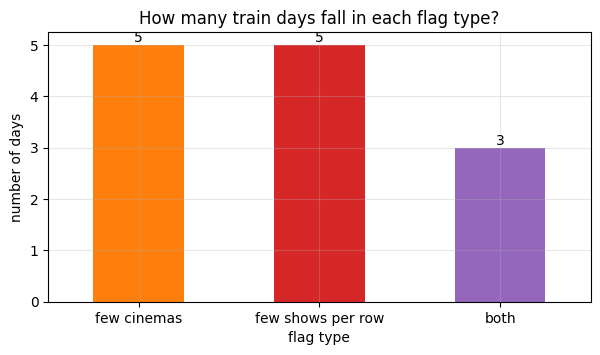

13 of 183 train days (7.1%) are flagged.
They hold 3.3% of all train rows.


In [27]:
order  = ["few cinemas", "few shows per row", "both"]
counts = daily.flag_type.value_counts().reindex(order).fillna(0).astype(int)

summary = counts.to_frame("days")
summary["% of train days"] = (summary.days / len(daily) * 100).round(1)
display(summary)

ax = counts.plot.bar(rot=0, figsize=(7, 3.5), color=["tab:orange", "tab:red", "tab:purple"])
ax.set_title("How many train days fall in each flag type?")
ax.set_xlabel("flag type"); ax.set_ylabel("number of days")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.show()

n_bad = int(bad.sum())
row_share = daily.loc[bad, "rows"].sum() / daily.rows.sum()
print(f"{n_bad} of {len(daily)} train days ({n_bad / len(daily):.1%}) are flagged.")
print(f"They hold {row_share:.1%} of all train rows.")

## Stage 9: Holiday effect and distance to holiday

**What to do**: See which holidays train has and which only test has. Then measure how far a holiday's effect reaches before and after the date. Then build simple distance features.

**Why**: Test contains holidays that train never saw, so the model cannot memorise them. Simple features like "distance to a holiday" can still carry over.

**What to look for**: Whether tickets per row rise on the holiday and the days around it, and how many examples sit behind each conclusion.

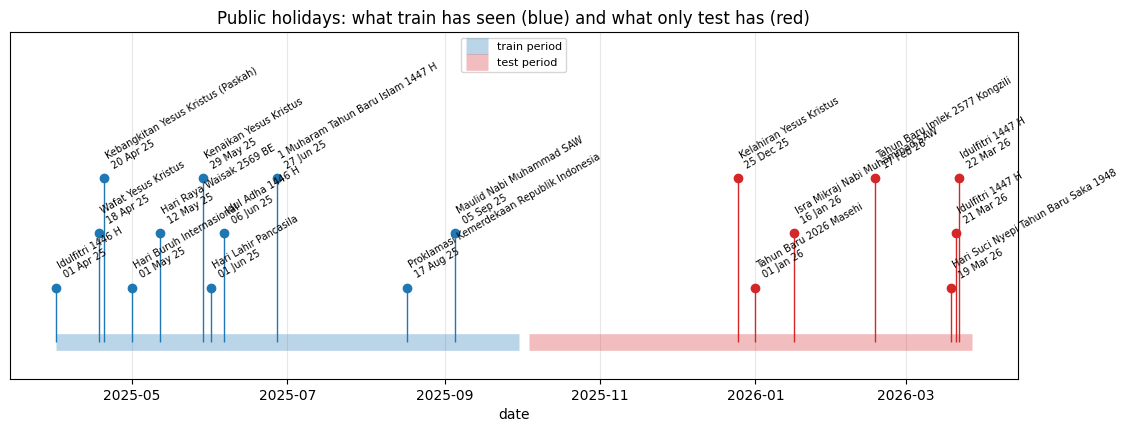

where
train          11
test period     7


In [28]:
hol = (holidays.loc[holidays.holiday_tipe == "holiday", ["date", "holiday_name"]]
               .sort_values("date").reset_index(drop=True))
t0, t1 = train.date_show.min(), train.date_show.max()
s0, s1 = test.date_show.min(),  test.date_show.max()

def where(d):
    if t0 <= d <= t1: return "train"
    if s0 <= d <= s1: return "test period"
    return "outside both"

hol["where"] = hol.date.map(where)
colors = {"train": "tab:blue", "test period": "tab:red", "outside both": "gray"}

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.hlines(0, t0, t1, color="tab:blue", lw=12, alpha=0.3, label="train period")
ax.hlines(0, s0, s1, color="tab:red",  lw=12, alpha=0.3, label="test period")
for i, r in hol.iterrows():
    y = 0.6 + (i % 3) * 0.6                    # stagger heights so labels do not overlap
    ax.vlines(r.date, 0, y, color=colors[r["where"]], lw=1)
    ax.plot(r.date, y, "o", color=colors[r["where"]])
    ax.text(r.date, y + 0.08, f"{r.holiday_name}\n{r.date:%d %b %y}",
            fontsize=7, rotation=30, ha="left", va="bottom")
ax.set_ylim(-0.4, 3.4); ax.set_yticks([])
ax.set_title("Public holidays: what train has seen (blue) and what only test has (red)")
ax.set_xlabel("date"); ax.legend(loc="upper center", fontsize=8)
plt.show()

print(hol["where"].value_counts().to_string())

,holiday,weekday,valid_days_of_7
2025-04-01,Idulfitri 1446 H,Tuesday,3
2025-04-18,Wafat Yesus Kristus,Friday,7
2025-04-20,Kebangkitan Yesus Kristus (Paskah),Sunday,7
2025-05-01,Hari Buruh Internasional,Thursday,7
2025-05-12,Hari Raya Waisak 2569 BE,Monday,7
2025-05-29,Kenaikan Yesus Kristus,Thursday,5
2025-06-01,Hari Lahir Pancasila,Sunday,3
2025-06-06,Idul Adha 1446 H,Friday,2
2025-06-27,1 Muharam Tahun Baru Islam 1447 H,Friday,7
2025-08-17,Proklamasi Kemerdekaan Republik Indonesia,Sunday,7


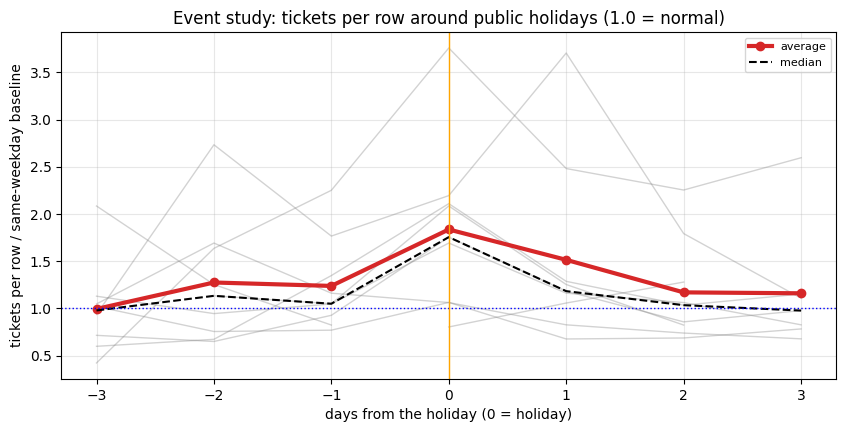

In [29]:
OFFSETS   = list(range(-3, 4))   # days from the holiday
MIN_VALID = 3                    # skip a holiday with fewer valid days than this

# tickets per row, but NaN on days flagged in Stage 8
clean = daily.tickets_per_row.where(daily.flag_type == "ok")

# reference series for baselines: holiday dates are blanked out too
hol_dates = pd.DatetimeIndex(hol.date)
ref = clean.copy()
ref[ref.index.isin(hol_dates)] = np.nan

def same_weekday_baseline(ref, dates, min_n=2):
    # average of the same weekday 1 and 2 weeks before and after (up to 4 days)
    shifted = [ref.reindex(dates + pd.Timedelta(days=k)).set_axis(dates) for k in (-14, -7, 7, 14)]
    vals = pd.concat(shifted, axis=1)
    return vals.mean(axis=1).where(vals.notna().sum(axis=1) >= min_n)   # need 2+ days

rel = {}
for h in hol_dates[(hol_dates >= t0) & (hol_dates <= t1)]:
    window = pd.DatetimeIndex([h + pd.Timedelta(days=k) for k in OFFSETS])
    ref_h = ref.copy()
    ref_h[ref_h.index.isin(window)] = np.nan     # keep the holiday window out of its own baseline
    base   = same_weekday_baseline(ref_h, window)
    actual = clean.reindex(window)               # NaN if outside train or flagged
    rel[h] = pd.Series((actual / base).values, index=OFFSETS)
rel = pd.DataFrame(rel).T

# table: which holidays have enough valid days?
names = hol.set_index("date").holiday_name
info = pd.DataFrame({
    "holiday": names.reindex(rel.index).values,
    "weekday": rel.index.day_name(),
    "valid_days_of_7": rel.notna().sum(axis=1).values,
}, index=rel.index.date)
display(info)

keep = rel.notna().sum(axis=1) >= MIN_VALID
fig, ax = plt.subplots(figsize=(10, 4.5))
for h, row in rel[keep].iterrows():
    ax.plot(OFFSETS, row.values, color="gray", alpha=0.35, lw=1)           # one faint line per holiday
ax.plot(OFFSETS, rel[keep].mean(axis=0).values,   color="tab:red", lw=3, marker="o", label="average")
ax.plot(OFFSETS, rel[keep].median(axis=0).values, color="black", lw=1.5, ls="--", label="median")
ax.axhline(1, color="blue", lw=1, ls=":")
ax.axvline(0, color="orange", lw=1)
ax.set_xlabel("days from the holiday (0 = holiday)")
ax.set_ylabel("tickets per row / same-weekday baseline")
ax.set_title("Event study: tickets per row around public holidays (1.0 = normal)")
ax.legend(fontsize=8)
plt.show()

,date,is_holiday,days_to_next,days_since_last,long_weekend
265,2025-12-22,False,3.0,108.0,False
266,2025-12-23,False,2.0,109.0,False
267,2025-12-24,False,1.0,110.0,False
268,2025-12-25,True,0.0,0.0,False
269,2025-12-26,False,6.0,1.0,False
270,2025-12-27,False,5.0,2.0,False
271,2025-12-28,False,4.0,3.0,False
272,2025-12-29,False,3.0,4.0,False
273,2025-12-30,False,2.0,5.0,False
274,2025-12-31,False,1.0,6.0,False


,days,rows,mean_ratio,median_ratio,mean_tickets_per_row
bucket,,,,,
0 (holiday),10,7636.0,1.74,1.72,594.81
1,9,6816.0,1.24,1.05,487.49
2,8,6124.0,1.22,1.04,368.59
3,6,5041.0,0.80,0.83,268.18
4-7,27,21789.0,0.92,0.88,374.95
8+,106,83810.0,1.04,0.97,337.02


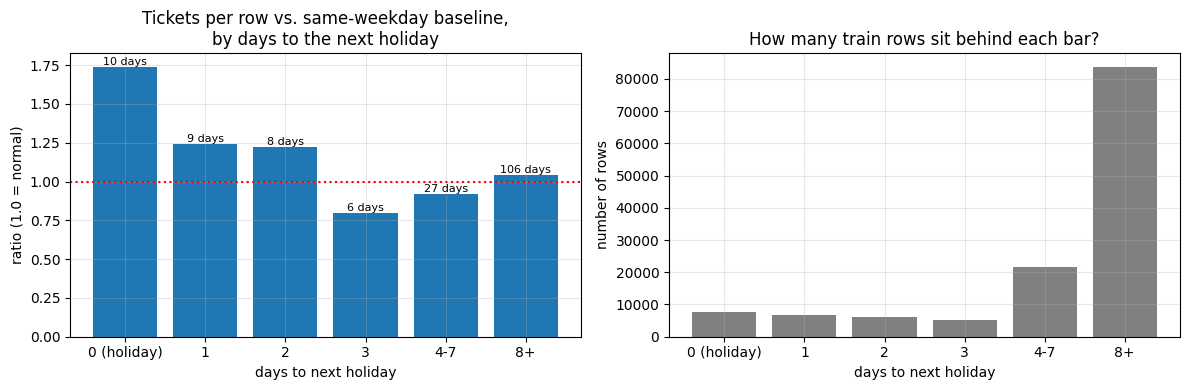

,days,mean_ratio
long_weekend,,
False,152,1.05
True,14,1.41


In [30]:
# --- build features for every date in holidays.csv (in memory only) ---
cal = pd.DataFrame({"date": holidays.date.sort_values().unique()})
cal["is_holiday"] = cal.date.isin(hol_dates)

h_arr = hol_dates.values
d_arr = cal.date.values

# days to the next holiday (0 if the day itself is a holiday)
nxt = np.searchsorted(h_arr, d_arr, side="left")
cal["days_to_next"] = np.where(
    nxt < len(h_arr),
    (h_arr[np.minimum(nxt, len(h_arr) - 1)] - d_arr) / np.timedelta64(1, "D"),
    np.nan)                                      # NaN = no later holiday in the file

# days since the last holiday (0 if the day itself is a holiday)
prv = np.searchsorted(h_arr, d_arr, side="right") - 1
cal["days_since_last"] = np.where(
    prv >= 0,
    (d_arr - h_arr[np.maximum(prv, 0)]) / np.timedelta64(1, "D"),
    np.nan)                                      # NaN = no earlier holiday in the file

# long weekend: a run of 3+ days off (Sat, Sun or holiday) that contains a holiday
off = (cal.date.dt.dayofweek >= 5) | cal.is_holiday
block = (off != off.shift()).cumsum()
block_len = off.groupby(block).transform("sum")
block_has_holiday = cal.is_holiday.groupby(block).transform("max").astype(bool)
cal["long_weekend"] = off & (block_len >= 3) & block_has_holiday

# quick check around New Year
display(cal[cal.date.between("2025-12-22", "2026-01-04")])

# --- day-level ratio to the same-weekday baseline (for every ok day) ---
base_all = same_weekday_baseline(ref, clean.index)
dd = pd.DataFrame({"ratio": clean / base_all, "tpr": clean, "rows": daily.rows, "flag": daily.flag_type})
dd = dd.join(cal.set_index("date")[["days_to_next", "days_since_last", "long_weekend"]])
dd = dd[dd.flag == "ok"].dropna(subset=["ratio", "days_to_next"])

dd["bucket"] = pd.cut(dd.days_to_next, bins=[-1, 0, 1, 2, 3, 7, np.inf],
                      labels=["0 (holiday)", "1", "2", "3", "4-7", "8+"])
out = dd.groupby("bucket", observed=True).agg(
    days=("ratio", "size"), rows=("rows", "sum"),
    mean_ratio=("ratio", "mean"), median_ratio=("ratio", "median"),
    mean_tickets_per_row=("tpr", "mean"),
).round(2)
display(out)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(out.index.astype(str), out.mean_ratio, color="tab:blue")
axes[0].axhline(1, color="red", ls=":")
for i, (v, n) in enumerate(zip(out.mean_ratio, out.days)):
    axes[0].text(i, v, f"{n} days", ha="center", va="bottom", fontsize=8)
axes[0].set_title("Tickets per row vs. same-weekday baseline,\nby days to the next holiday")
axes[0].set_xlabel("days to next holiday"); axes[0].set_ylabel("ratio (1.0 = normal)")
axes[1].bar(out.index.astype(str), out.rows, color="gray")
axes[1].set_title("How many train rows sit behind each bar?")
axes[1].set_xlabel("days to next holiday"); axes[1].set_ylabel("number of rows")
plt.tight_layout(); plt.show()

# does the long-weekend flag add anything? (same-weekday ratio, so weekends are fair)
display(dd.groupby("long_weekend").agg(days=("ratio", "size"), mean_ratio=("ratio", "mean")).round(2))

## Stage 10: Cleaning

In [31]:
# ---------- SETTINGS (change values only here) ----------
BAD_START  = "2025-06-01"   # first masked day
BAD_END    = "2025-06-16"   # last masked day
KEEP_DATES = []             # days inside the block to keep, e.g. ["2025-06-06"]
MAX_GAP    = 3              # used only by the optional gap helper (Cell 10.8)

# ---------- Remember raw sizes and columns (checked again in Cell 10.9) ----------
raw_len = {"train": len(train), "test_hist": len(test_hist), "test": len(test),
           "movies": len(movies), "holidays": len(holidays),
           "prices": len(prices), "ext_meta": len(ext_meta)}
raw_cols = {"train": list(train.columns), "test_hist": list(test_hist.columns),
            "test": list(test.columns), "movies": list(movies.columns)}

# ---------- Small helpers ----------
def show(df):
    print(df.to_string(index=False))

cleaning_log = {}   # one entry per rule; safe to re-run a cell
def log_rule(rule_id, what, rows, base, action):
    pct = round(100 * rows / base, 3) if base else 0.0
    cleaning_log[rule_id] = {"rule ID": rule_id, "what": what, "rows affected": int(rows),
                             "percent of rows": pct, "action taken": action}

# ---------- Rule list ----------
rules = pd.DataFrame([
    ["R01", "Duplicate rows on (date, cinema, movie title)",        "REPORT"],
    ["R02", "Date overlap between train, test_hist and test",       "REPORT"],
    ["R03", "Each cinema belongs to exactly one city",              "REPORT"],
    ["R04", "Test cinemas and cities not seen in train",            "REPORT"],
    ["R05", "total_ticket < 1",                                     "REPORT"],
    ["R06", "occupation_rate outside 0 to 100",                     "REPORT"],
    ["R07", "total_show < 1",                                       "REPORT"],
    ["R08", "tickets > 0 but total_show == 0",                      "REPORT"],
    ["R09", "Hidden spaces, non-breaking spaces, case in text keys","AUTO"],
    ["R10", "Bad-date mask (is_bad_day)",                           "SETTING"],
    ["R11", "Duplicate movie_base in movies",                       "REPORT"],
    ["R12", "Genre to list; empty age_rating to UNKNOWN",           "AUTO"],
    ["R13", "Every movie_base has exactly one match in movies",     "REPORT"],
    ["R14", "Holidays: unique, continuous, weekday label correct",  "REPORT"],
    ["R15", "Every city has all 3 price_day values",                "REPORT"],
    ["R16", "Fill short gaps with 0 (optional helper)",             "SETTING"],
], columns=["ID", "what it checks", "action type"])
show(rules)

 ID                                        what it checks action type
R01         Duplicate rows on (date, cinema, movie title)      REPORT
R02        Date overlap between train, test_hist and test      REPORT
R03               Each cinema belongs to exactly one city      REPORT
R04             Test cinemas and cities not seen in train      REPORT
R05                                      total_ticket < 1      REPORT
R06                      occupation_rate outside 0 to 100      REPORT
R07                                        total_show < 1      REPORT
R08                       tickets > 0 but total_show == 0      REPORT
R09 Hidden spaces, non-breaking spaces, case in text keys        AUTO
R10                            Bad-date mask (is_bad_day)     SETTING
R11                        Duplicate movie_base in movies      REPORT
R12            Genre to list; empty age_rating to UNKNOWN        AUTO
R13      Every movie_base has exactly one match in movies      REPORT
R14   Holidays: uniq

In [32]:
key3 = ["date_show", "cinema_ids", "movie_title"]
tables = {"train": train, "test_hist": test_hist, "test": test}

# 1) Duplicates on date + cinema + title (different formats have different titles)
dup_table = pd.DataFrame([{"table": n, "rows": len(d),
                           "rows_in_duplicate_groups": int(d.duplicated(key3, keep=False).sum())}
                          for n, d in tables.items()])
show(dup_table)
for n, d in tables.items():
    ex = d[d.duplicated(key3, keep=False)].sort_values(key3).head(10)
    if len(ex):
        print(f"\nExamples of duplicates in {n}:")
        show(ex)

# 2) Date overlap for the same pair (same cinema + title + date in both tables)
def overlap_rows(a, b):
    return a[key3].drop_duplicates().merge(b[key3].drop_duplicates(), on=key3, how="inner")

ov_tr_th = overlap_rows(train, test_hist)
ov_th_te = overlap_rows(test_hist, test)
print("\nOverlap train vs test_hist:", len(ov_tr_th))
print("Overlap test_hist vs test :", len(ov_th_te))
for name, ov in [("train vs test_hist", ov_tr_th), ("test_hist vs test", ov_th_te)]:
    if len(ov):
        print(f"Examples ({name}):")
        show(ov.head(10))

# 3) One city per cinema across all three tables
cc = pd.concat([d[["cinema_ids", "city_name"]] for d in tables.values()]).drop_duplicates()
cities_per_cinema = cc.groupby("cinema_ids")["city_name"].nunique()
bad_cinemas = cities_per_cinema[cities_per_cinema > 1].index
print("\nCinemas with more than one city:", len(bad_cinemas))
if len(bad_cinemas):
    show(cc[cc["cinema_ids"].isin(bad_cinemas)].sort_values("cinema_ids"))

# 4) Test cinemas and cities that train has never seen
seen_cin, seen_city = set(train["cinema_ids"]), set(train["city_name"])
hist_counts = test_hist["cinema_ids"].value_counts()

new_cin = (test[~test["cinema_ids"].isin(seen_cin)]
           .groupby(["cinema_ids", "city_name"]).size().reset_index(name="test_rows"))
new_cin["test_hist_rows"] = new_cin["cinema_ids"].map(hist_counts).fillna(0).astype(int)
new_city = (test[~test["city_name"].isin(seen_city)]
            .groupby("city_name").size().reset_index(name="test_rows"))

print("\nTest cinemas not in train:", len(new_cin))
show(new_cin)
print("\nTest cities not in train:", len(new_city))
show(new_city)

# ---- log ----
n_all = len(train) + len(test_hist) + len(test)
unseen_rows = int((~test["cinema_ids"].isin(seen_cin) | ~test["city_name"].isin(seen_city)).sum())
log_rule("R01", "Duplicate rows (3 tables)", dup_table["rows_in_duplicate_groups"].sum(), n_all, "reported only")
log_rule("R02", "Date overlaps (pair+date)", len(ov_tr_th) + len(ov_th_te), n_all, "reported only")
log_rule("R03", "Cinemas with >1 city (rows)",
         sum(int(d["cinema_ids"].isin(bad_cinemas).sum()) for d in tables.values()), n_all, "reported only")
log_rule("R04", "Test rows with unseen cinema/city", unseen_rows, len(test), "reported only")

    table   rows  rows_in_duplicate_groups
    train 138959                         0
test_hist  32323                         0
     test  72611                         0

Overlap train vs test_hist: 0
Overlap test_hist vs test : 0

Cinemas with more than one city: 0

Test cinemas not in train: 4
                      cinema_ids city_name  test_rows  test_hist_rows
2df461316312ad73a45a7b7354c24014  MAGELANG        161              72
ab66df99207da01f3e300ef0163a1d2e     BOGOR        252             118
ea8d354888b056f56de16e2ce54e3415   CIANJUR         28              13
f3432c52947b6412b4973fa6bf23d666     TUBAN        161              78

Test cities not in train: 2
city_name  test_rows
 MAGELANG        161
    TUBAN        161


    table                           check  rows
    train                total_ticket < 1     0
    train   occupation_rate outside 0-100     0
    train                  total_show < 1     0
    train tickets > 0 but total_show == 0     0
test_hist                total_ticket < 1     0
test_hist   occupation_rate outside 0-100     0
test_hist                  total_show < 1     0
test_hist tickets > 0 but total_show == 0     0

Missing values:
                 train  test_hist
total_ticket         0          0
occupation_rate      0          0
total_show           0          0


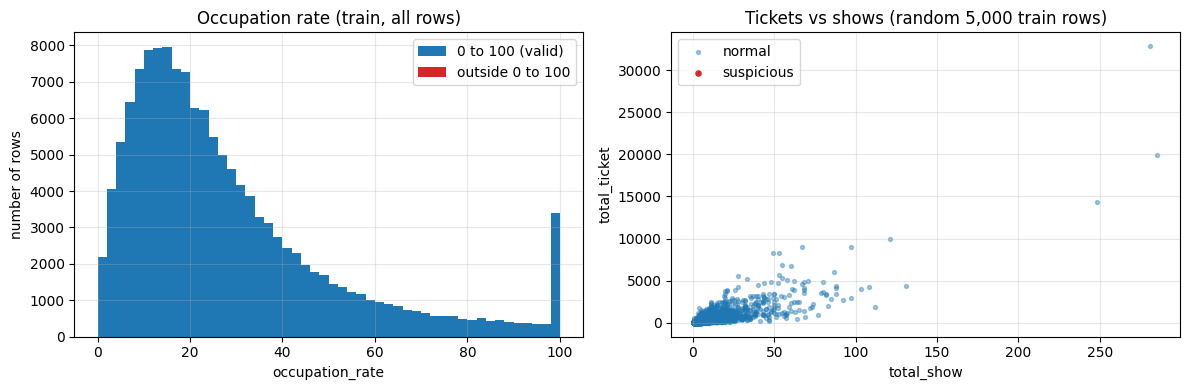

In [34]:
checks = {
    "total_ticket < 1":               lambda d: d["total_ticket"] < 1,
    "occupation_rate outside 0-100":  lambda d: (d["occupation_rate"] < 0) | (d["occupation_rate"] > 100),
    "total_show < 1":                 lambda d: d["total_show"] < 1,
    "tickets > 0 but total_show == 0": lambda d: (d["total_ticket"] > 0) & (d["total_show"] == 0),
}
sets = {"train": train, "test_hist": test_hist}
show_cols = ["date_show", "cinema_ids", "movie_title", "total_ticket", "occupation_rate", "total_show"]

flags, summary = {}, []
for tname, df in sets.items():
    flags[tname] = {c: f(df) for c, f in checks.items()}
    for c, mask in flags[tname].items():
        summary.append({"table": tname, "check": c, "rows": int(mask.sum())})
show(pd.DataFrame(summary))

# Missing values in the three columns
print("\nMissing values:")
print(pd.concat({n: d[["total_ticket", "occupation_rate", "total_show"]].isna().sum()
                 for n, d in sets.items()}, axis=1))

# Up to 10 example rows per problem
for tname, df in sets.items():
    for c, mask in flags[tname].items():
        if mask.sum() > 0:
            print(f"\n{tname} | {c} | first 10 of {int(mask.sum())}")
            show(df.loc[mask, show_cols].head(10))

# ---- charts ----
samp = train.sample(n=min(5000, len(train)), random_state=42)
any_bad = pd.Series(False, index=samp.index)
for c, mask in flags["train"].items():
    any_bad |= mask.loc[samp.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

occ = train["occupation_rate"].dropna()
outside = (occ < 0) | (occ > 100)
bins = np.linspace(min(0, occ.min()), max(100, occ.max()), 51)
axes[0].hist(occ[~outside], bins=bins, color="tab:blue", label="0 to 100 (valid)")
axes[0].hist(occ[outside], bins=bins, color="tab:red", label="outside 0 to 100")
axes[0].set_title("Occupation rate (train, all rows)")
axes[0].set_xlabel("occupation_rate")
axes[0].set_ylabel("number of rows")
axes[0].legend(); axes[0].grid(True)

axes[1].scatter(samp.loc[~any_bad, "total_show"], samp.loc[~any_bad, "total_ticket"],
                s=8, alpha=0.4, color="tab:blue", label="normal")
axes[1].scatter(samp.loc[any_bad, "total_show"], samp.loc[any_bad, "total_ticket"],
                s=14, color="tab:red", label="suspicious")
axes[1].set_title("Tickets vs shows (random 5,000 train rows)")
axes[1].set_xlabel("total_show")
axes[1].set_ylabel("total_ticket")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

# ---- log ----
base = len(train) + len(test_hist)
for rid, c in zip(["R05", "R06", "R07", "R08"], checks.keys()):
    n = sum(int(flags[t][c].sum()) for t in sets)
    log_rule(rid, c + " (train+hist)", n, base, "reported only")

  example in train.movie_title: 'MISSION: IMPOSSIBLE - THE FINAL RECKONING (IMAX 2D) '
    table      column  rows_with_hidden_chars  unique_values_affected  missing
    train movie_title                     268                       1        0
    train  movie_base                       0                       0        0
    train  cinema_ids                       0                       0        0
    train   city_name                       0                       0        0
test_hist movie_title                       0                       0        0
test_hist  movie_base                       0                       0        0
test_hist  cinema_ids                       0                       0        0
test_hist   city_name                       0                       0        0
     test movie_title                       0                       0        0
     test  movie_base                       0                       0        0
     test  cinema_ids                       

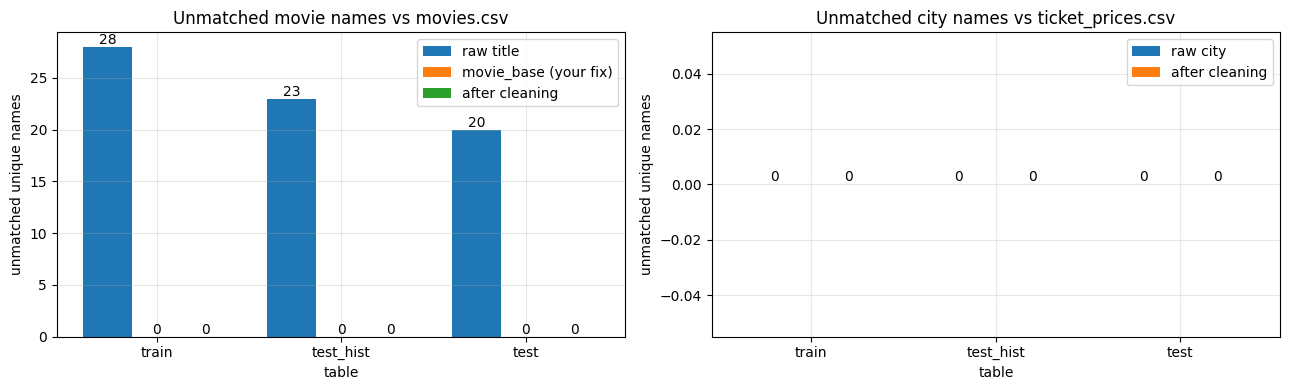

train: duplicate rows raw = 0, after cleaning = 0
test_hist: duplicate rows raw = 0, after cleaning = 0
test: duplicate rows raw = 0, after cleaning = 0
Unseen test cinemas after cleaning: 4
Rows where a key text changed: 268


In [36]:
LOWERCASE_KEYS = False   # set True ONLY if the case report below shows real case differences

# Python regex: hidden characters, spaces at the edges, or double spaces
HIDDEN = re.compile(r"[\u00a0\u2007\u202f\u200b\u200c\u200d\u2060\ufeff\t\r\n]|^\s|\s$|\s{2,}")

def clean_text(s, lower=False):
    if not isinstance(s, str):          # leave NaN and numbers untouched
        return s
    s = re.sub(r"[\u200b\u200c\u200d\u2060\ufeff]", "", s)   # zero-width characters
    s = re.sub(r"[\u00a0\u2007\u202f]", " ", s)              # non-breaking spaces become normal spaces
    s = re.sub(r"\s+", " ", s).strip()                       # one space only, no edge spaces
    return s.lower() if lower else s

def clean_col(s, lower=False):
    mapping = {v: clean_text(v, lower) for v in s.dropna().unique()}   # clean unique values only (fast)
    return s.map(mapping)

# ---- 1) Hidden characters report (raw tables) ----
key_cols = ["movie_title", "movie_base", "cinema_ids", "city_name"]
text_cols = {"train": (train, key_cols), "test_hist": (test_hist, key_cols),
             "test": (test, key_cols), "prices": (prices, ["city_name"])}
rows = []
for tname, (df, cols) in text_cols.items():
    for c in cols:
        s = df[c]
        uniq = s.dropna().astype(str).drop_duplicates()                    # unique names only
        bad_vals = set(uniq[uniq.map(lambda v: bool(HIDDEN.search(v)))])   # names with hidden characters
        bad = s.isin(bad_vals)                                             # rows that use those names
        rows.append({"table": tname, "column": c, "rows_with_hidden_chars": int(bad.sum()),
                     "unique_values_affected": len(bad_vals), "missing": int(s.isna().sum())})
        for v in list(bad_vals)[:3]:
            print(f"  example in {tname}.{c}: {v!r}")
show(pd.DataFrame(rows))

# ---- 2) Case differences and merged spellings (unique values, all tables) ----
case_rows = []
for c in key_cols:
    vals = pd.concat([train[c], test_hist[c], test[c]] + ([prices[c]] if c == "city_name" else []))
    vals = vals.dropna().drop_duplicates()
    sq = vals.map(lambda x: clean_text(x)).drop_duplicates()    # spaces fixed, case kept
    low_dup = sq.str.lower().duplicated(keep=False)
    case_rows.append({"column": c, "unique_raw": len(vals), "unique_after_space_fix": len(sq),
                      "values_that_differ_only_by_case": int(low_dup.sum())})
    if low_dup.any():
        print(f"  case examples in {c}:", list(sq[low_dup].sort_values().head(6)))
show(pd.DataFrame(case_rows))

# ---- 3) Build the clean copies (raw tables stay untouched) ----
train_clean, test_hist_clean, test_clean = train.copy(), test_hist.copy(), test.copy()
prices_clean = prices.copy()
for df in (train_clean, test_hist_clean, test_clean):
    for c in key_cols:
        df[c + "_clean"] = clean_col(df[c], LOWERCASE_KEYS)
prices_clean["city_name_clean"] = clean_col(prices["city_name"], LOWERCASE_KEYS)

assert len(train_clean) == len(train) and len(test_hist_clean) == len(test_hist) \
       and len(test_clean) == len(test), "row count changed!"

# ---- 4) Unmatched names before vs after (merge with validate) ----
movies_base_clean = clean_col(movies["movie_base"], LOWERCASE_KEYS)

def match_check(df, col, ref_values):
    ref = pd.DataFrame({col: pd.Series(ref_values).dropna().unique()})
    ref["_found"] = True
    out = df[[col]].merge(ref, on=col, how="left", validate="many_to_one")
    assert len(out) == len(df), "merge changed the row count"
    miss = (out["_found"].isna() & out[col].notna()).to_numpy()
    return int(miss.sum()), int(df.loc[miss, col].nunique())   # (rows, unique names)

pairs = {"train": (train, train_clean), "test_hist": (test_hist, test_hist_clean), "test": (test, test_clean)}
t_res, c_res = [], []
for n, (raw_df, cl) in pairs.items():
    t_raw  = match_check(raw_df, "movie_title", movies["original_title"])
    t_base = match_check(raw_df, "movie_base", movies["movie_base"])
    t_cl   = match_check(cl, "movie_base_clean", movies_base_clean)
    c_raw  = match_check(raw_df, "city_name", prices["city_name"])
    c_cl   = match_check(cl, "city_name_clean", prices_clean["city_name_clean"])
    t_res.append({"table": n, "raw_title_rows": t_raw[0], "raw_title_unique": t_raw[1],
                  "movie_base_unique": t_base[1], "clean_unique": t_cl[1], "clean_rows": t_cl[0]})
    c_res.append({"table": n, "raw_city_rows": c_raw[0], "raw_city_unique": c_raw[1],
                  "clean_unique": c_cl[1], "clean_rows": c_cl[0]})
t_res, c_res = pd.DataFrame(t_res), pd.DataFrame(c_res)
print("\nUnmatched movie names:");  show(t_res)
print("\nUnmatched city names:");   show(c_res)

def grouped_bar(ax, labels, series, title, ylabel):
    width = 0.8 / len(series)
    x = np.arange(len(labels))
    for i, (name, vals) in enumerate(series.items()):
        bars = ax.bar(x - 0.4 + width / 2 + i * width, vals, width, label=name)
        ax.bar_label(bars)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_title(title); ax.set_xlabel("table"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, axis="y")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
grouped_bar(axes[0], t_res["table"],
            {"raw title": t_res["raw_title_unique"], "movie_base (your fix)": t_res["movie_base_unique"],
             "after cleaning": t_res["clean_unique"]},
            "Unmatched movie names vs movies.csv", "unmatched unique names")
grouped_bar(axes[1], c_res["table"],
            {"raw city": c_res["raw_city_unique"], "after cleaning": c_res["clean_unique"]},
            "Unmatched city names vs ticket_prices.csv", "unmatched unique names")
plt.tight_layout(); plt.show()

# ---- 5) Did cleaning change duplicates or unseen cinemas? ----
clean_key3 = ["date_show", "cinema_ids_clean", "movie_title_clean"]
for n, (raw_df, cl) in pairs.items():
    print(f"{n}: duplicate rows raw = {int(raw_df.duplicated(key3, keep=False).sum())}, "
          f"after cleaning = {int(cl.duplicated(clean_key3, keep=False).sum())}")
unseen_after = test_clean.loc[~test_clean["cinema_ids_clean"].isin(set(train_clean["cinema_ids_clean"])),
                              "cinema_ids_clean"].nunique()
print("Unseen test cinemas after cleaning:", unseen_after)

# ---- log: rows where any key text actually changed ----
changed_rows = 0
for df in (train_clean, test_hist_clean, test_clean):
    chg = pd.Series(False, index=df.index)
    for c in key_cols:
        chg |= df[c].fillna("<NA>") != df[c + "_clean"].fillna("<NA>")
    changed_rows += int(chg.sum())
print("Rows where a key text changed:", changed_rows)
log_rule("R09", "Rows with changed key text (3 tables)", changed_rows, n_all,
         "AUTO: *_clean columns added to copies")

Masked days: 16  (2025-06-01 to 2025-06-16)
Kept inside block: []
Test helper (inside block): True
Test helper (outside)     : False

Days in train inside the mask: 15
Rows marked is_bad_day: 6699 (4.82% of train)
Pairs with at least one marked row: 1834 of 13041

Flagged days OUTSIDE the mask: 0
Days INSIDE the mask that were NOT flagged: 3
      date  rows  cinemas  shows_per_row  tickets_per_row flag_type
2025-06-06 747.0    105.0       5.307898       291.812584        ok
2025-06-08 665.0    115.0       6.007519       299.332331        ok
2025-06-12 718.0    112.0       5.557103       180.040390        ok


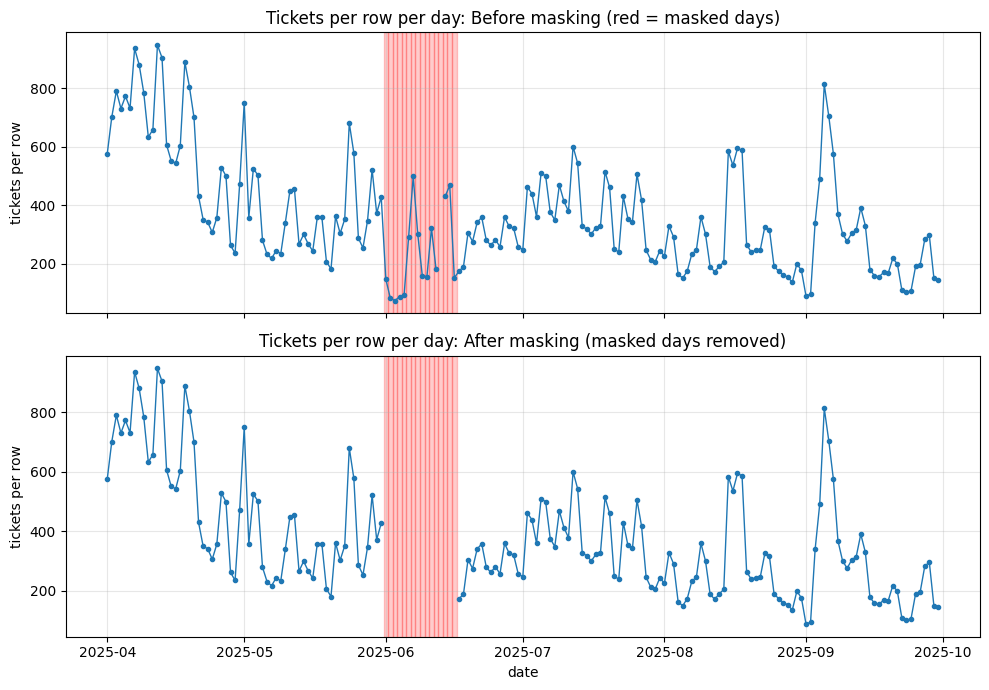

In [37]:
DAILY_DATE_COL = "date_show"   # change if your daily table uses another date column name

# ---- build bad_dates from the settings ----
bad_dates = pd.date_range(BAD_START, BAD_END, freq="D")
keep = pd.DatetimeIndex(pd.to_datetime(KEEP_DATES))
outside_keep = keep.difference(bad_dates)
if len(outside_keep):
    print("Warning: KEEP_DATES outside the block (ignored):", list(outside_keep.date))
bad_dates = bad_dates.difference(keep)
print(f"Masked days: {len(bad_dates)}  ({bad_dates.min().date()} to {bad_dates.max().date()})")
print("Kept inside block:", [str(d.date()) for d in keep])

# ---- helper: does a date range touch a masked day? ----
def window_touches_bad(start, end):
    days = pd.date_range(pd.to_datetime(start), pd.to_datetime(end), freq="D")
    return bool(days.isin(bad_dates).any())

print("Test helper (inside block):", window_touches_bad("2025-06-10", "2025-06-12"))
print("Test helper (outside)     :", window_touches_bad("2025-07-01", "2025-07-07"))

# ---- mark rows (no deletion) ----
train_clean["is_bad_day"] = train_clean["date_show"].dt.normalize().isin(bad_dates)
assert len(train_clean) == len(train)

n_days  = train_clean.loc[train_clean["is_bad_day"], "date_show"].nunique()
n_rows  = int(train_clean["is_bad_day"].sum())
n_pairs = train_clean.loc[train_clean["is_bad_day"], keys].drop_duplicates().shape[0]
all_pairs = train_clean[keys].drop_duplicates().shape[0]
print(f"\nDays in train inside the mask: {n_days}")
print(f"Rows marked is_bad_day: {n_rows} ({100 * n_rows / len(train_clean):.2f}% of train)")
print(f"Pairs with at least one marked row: {n_pairs} of {all_pairs}")

# ---- cross-check with your daily.flag_type ----
d = daily.copy()
if DAILY_DATE_COL in d.columns:
    d["date"] = pd.to_datetime(d[DAILY_DATE_COL])
else:
    d["date"] = pd.to_datetime(d.index)         # the date is the index
flagged = d["flag_type"] != "ok"
in_mask = d["date"].isin(bad_dates)
cols = [c for c in ["date", "rows", "cinemas", "shows_per_row", "tickets_per_row", "flag_type"] if c in d.columns]

out_flag = d.loc[flagged & ~in_mask, cols]
in_ok    = d.loc[~flagged & in_mask, cols]
print(f"\nFlagged days OUTSIDE the mask: {len(out_flag)}")
if len(out_flag): show(out_flag)
print(f"Days INSIDE the mask that were NOT flagged: {len(in_ok)}")
if len(in_ok): show(in_ok)

# ---- chart: before and after masking ----
y_before = d.set_index("date")["tickets_per_row"].sort_index()
y_after = y_before.mask(y_before.index.isin(bad_dates))

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for ax, y, ttl in zip(axes, [y_before, y_after],
                      ["Before masking (red = masked days)", "After masking (masked days removed)"]):
    ax.plot(y.index, y.values, marker=".", linewidth=1)
    for day in bad_dates:
        ax.axvspan(day - pd.Timedelta(hours=12), day + pd.Timedelta(hours=12), color="red", alpha=0.2)
    ax.set_title("Tickets per row per day: " + ttl)
    ax.set_ylabel("tickets per row")
    ax.grid(True)
axes[1].set_xlabel("date")
plt.tight_layout(); plt.show()

log_rule("R10", "Rows marked is_bad_day (train)", n_rows, len(train),
         f"SETTING: marked {len(bad_dates)} days, no rows deleted")

In [38]:
movies_clean = movies.copy()
movies_clean["movie_base_clean"] = clean_col(movies["movie_base"], LOWERCASE_KEYS)

# ---- 1) duplicates on movie_base ----
dup_m = movies_clean[movies_clean.duplicated("movie_base_clean", keep=False)].sort_values("movie_base_clean")
print("Movie rows in duplicate groups:", len(dup_m))
if len(dup_m):
    show(dup_m[["original_title", "movie_base_clean", "age_rating", "genre"]])
else:
    print("No duplicates: nothing to fix.")

# ---- 2) genre text to a clean list ----
movies_clean["genre_list"] = movies_clean["genre"].fillna("").map(
    lambda s: [clean_text(g) for g in str(s).split(",") if clean_text(g)])
print("\nMovies with no genre:", int((movies_clean["genre_list"].str.len() == 0).sum()))
show(movies_clean[["original_title", "genre", "genre_list"]].head(5))
print("\nMost common genres:")
print(movies_clean["genre_list"].explode().value_counts().head(10))

# ---- 3) empty age_rating becomes UNKNOWN ----
age = movies_clean["age_rating"].map(lambda s: clean_text(s) if pd.notna(s) else s).replace("", np.nan)
empty = age.isna()
print("\nEmpty age_rating:", int(empty.sum()), "(you expected 3)")
show(movies_clean.loc[empty, ["original_title", "genre"]])
movies_clean["age_rating"] = age.fillna("UNKNOWN")

# ---- 4) every movie_base has exactly one match ----
# validate="many_to_one" raises an error if movies_clean has duplicate keys
for n, df in {"train": train_clean, "test_hist": test_hist_clean, "test": test_clean}.items():
    m = df[["movie_base_clean"]].merge(movies_clean[["movie_base_clean"]], on="movie_base_clean",
                                       how="left", validate="many_to_one", indicator=True)
    n_missing = int((m["_merge"] != "both").sum())
    assert len(m) == len(df), f"{n}: row count changed"
    assert n_missing == 0, f"{n}: {n_missing} rows have no movie match"
    print(f"{n}: all {len(df)} rows match exactly one movie")

print("\next_meta untouched, shape:", ext_meta.shape)

# ---- log ----
log_rule("R11", "Rows in duplicate movie_base groups", len(dup_m), len(movies), "reported only")
log_rule("R12", "Empty age_rating set to UNKNOWN", int(empty.sum()), len(movies), "AUTO: UNKNOWN in movies_clean")
log_rule("R13", "Rows without exactly one movie match", 0, n_all, "assert passed (else error above)")

Movie rows in duplicate groups: 0
No duplicates: nothing to fix.

Movies with no genre: 0
                      original_title       genre    genre_list
                         120 BAHADUR Action, War [Action, War]
                  13 DAYS, 13 NIGHTS Action, War [Action, War]
                      28 YEARS LATER    Thriller    [Thriller]
     28 YEARS LATER: THE BONE TEMPLE    Thriller    [Thriller]
5 CENTIMETERS PER SECOND (ANIMATION)   Animation   [Animation]

Most common genres:
genre_list
Drama        146
Horror       111
Action        67
Thriller      57
Comedy        57
Romance       37
Animation     32
Family        25
Fantasy       21
Adventure     16
Name: count, dtype: int64

Empty age_rating: 3 (you expected 3)
                               original_title               genre
           MLBB: M7 WATCH PARTY - TIER LEGEND Live Stream, eSport
           MLBB: M7 WATCH PARTY - TIER MYTHIC Live Stream, eSport
TWENTY ONE PILOTS: MORE THAN WE EVER IMAGINED  Music, Documentary
tr

In [39]:
# ---- holidays ----
h = holidays.copy()
h["date"] = pd.to_datetime(h["date"])

n_dup_dates = int(h["date"].duplicated().sum())
full = pd.date_range(h["date"].min(), h["date"].max(), freq="D")
missing_days = full.difference(pd.DatetimeIndex(h["date"]))
print("Date range:", h["date"].min().date(), "to", h["date"].max().date())
print("Duplicate dates:", n_dup_dates, "| Missing days in the range:", len(missing_days))
if len(missing_days): print(list(missing_days.date[:10]))

# day_tipe must match the real weekday: Mon-Thu weekday, Fri friday, Sat-Sun weekend
expected = h["date"].dt.dayofweek.map(lambda k: "friday" if k == 4 else ("weekend" if k >= 5 else "weekday"))
actual = h["day_tipe"].astype(str).str.strip().str.lower()
mism = h[expected != actual].copy()
mism["expected"] = expected[mism.index]
mism["weekday_name"] = mism["date"].dt.day_name()
print("\nday_tipe mismatches:", len(mism))
if len(mism):
    print(mism["holiday_tipe"].value_counts().to_string())
    show(mism[["date", "weekday_name", "day_tipe", "expected", "holiday_tipe", "holiday_name"]].head(20))

# the end of the file
last = h["date"].max()
margin = (last - test["date_show"].max()).days
print("\nLast holiday date:", last.date(), "| last test date:", test["date_show"].max().date(),
      "| margin (days):", margin)
for n, df in {"train": train, "test_hist": test_hist, "test": test}.items():
    n_out = int((~df["date_show"].dt.normalize().isin(h["date"])).sum())
    print(f"{n}: rows with a date missing from the holiday file = {n_out}")

# ---- prices ----
prices_clean["price_day_clean"] = prices["price_day"].astype("string").str.strip().str.title()
need = {"Weekday", "Friday", "Weekend"}
have = {c: set(g["price_day_clean"].dropna()) for c, g in prices_clean.groupby("city_name_clean")}
print("\nRows per city in price table:", prices_clean.groupby("city_name_clean").size().value_counts().to_dict())
print("Duplicate (city, price_day):", int(prices_clean.duplicated(["city_name_clean", "price_day_clean"]).sum()))

problems = []
for n, df in {"train": train_clean, "test_hist": test_hist_clean, "test": test_clean}.items():
    for city, n_rows in df["city_name_clean"].value_counts(dropna=False).items():
        miss = need - have.get(city, set())
        if miss:
            problems.append({"table": n, "city": city, "rows": int(n_rows),
                             "missing_price_days": ", ".join(sorted(miss))})
if problems:
    print("\nCities without all 3 price types:")
    show(pd.DataFrame(problems))
else:
    print("\nAll cities have all 3 price types: nothing to fix.")

# ---- log ----
log_rule("R14", "Holiday file problems (dup + gaps + wrong label)",
         n_dup_dates + len(missing_days) + len(mism), len(h), "reported only")
log_rule("R15", "Rows in cities missing a price type",
         sum(p["rows"] for p in problems), n_all, "reported only")

Date range: 2025-04-01 to 2026-04-01
Duplicate dates: 0 | Missing days in the range: 0

day_tipe mismatches: 0

Last holiday date: 2026-04-01 | last test date: 2026-03-27 | margin (days): 5
train: rows with a date missing from the holiday file = 0
test_hist: rows with a date missing from the holiday file = 0
test: rows with a date missing from the holiday file = 0

Rows per city in price table: {3: 69}
Duplicate (city, price_day): 0

All cities have all 3 price types: nothing to fix.
